# Olist E-Commerce Analytics
**Data Analytics Hackathon 2026**

Brazilian e-commerce public dataset by Olist — ~100k orders, Sep 2016 to Oct 2018.

---
## Table of Contents
1. Setup and Data Understanding
   - 1.1 Imports and Global Style
   - 1.2 Load All Datasets
   - 1.3 Dataset Validation
   - 1.4 Schema and Relationship Map


# Section 1 - Setup and Data Understanding

Sanity checks: confirm shapes, dtypes, nulls, and primary-key uniqueness before any analysis.


## 1.1 Imports and Global Style


In [166]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.4f}'.format)

PALETTE    = ['#6C5CE7', '#00B894', '#FDCB6E', '#E17055', '#74B9FF',
              '#A29BFE', '#55EFC4', '#FD79A8', '#0984E3', '#D63031']
BG_COLOR   = '#0F0F1A'
GRID_COLOR = '#2D2D44'
TEXT_COLOR = '#E0E0F0'
ACCENT     = '#6C5CE7'

plt.rcParams.update({
    'figure.facecolor'   : BG_COLOR,
    'figure.dpi'         : 130,
    'axes.facecolor'     : '#16162A',
    'axes.edgecolor'     : GRID_COLOR,
    'axes.labelcolor'    : TEXT_COLOR,
    'axes.titlecolor'    : TEXT_COLOR,
    'axes.titlesize'     : 13,
    'axes.labelsize'     : 11,
    'axes.grid'          : True,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'grid.color'         : GRID_COLOR,
    'grid.linewidth'     : 0.6,
    'grid.alpha'         : 0.7,
    'xtick.color'        : TEXT_COLOR,
    'ytick.color'        : TEXT_COLOR,
    'xtick.labelsize'    : 9,
    'ytick.labelsize'    : 9,
    'legend.facecolor'   : '#1E1E32',
    'legend.edgecolor'   : GRID_COLOR,
    'legend.labelcolor'  : TEXT_COLOR,
    'legend.fontsize'    : 9,
    'font.family'        : 'DejaVu Sans',
    'text.color'         : TEXT_COLOR,
})
sns.set_palette(PALETTE)

print(f'pandas {pd.__version__} | numpy {np.__version__} | seaborn {sns.__version__}')


pandas 2.3.3 | numpy 2.2.6 | seaborn 0.13.2


## 1.2 Load All Datasets


In [167]:
import os

DATA_DIR = 'Dataset'

DATASET_REGISTRY = {
    'orders'              : ('orders.csv',               'order_id',                      99441),
    'order_items'         : ('order_items.csv',          ['order_id', 'order_item_id'],  112650),
    'order_payments'      : ('order_payments.csv',       ['order_id', 'payment_sequential'], None),
    'order_reviews'       : ('order_reviews.csv',        'review_id',                     99224),
    'customers'           : ('customers.csv',            'customer_id',                   99441),
    'products'            : ('products.csv',             'product_id',                    32951),
    'sellers'             : ('sellers.csv',              'seller_id',                      3095),
    'geolocation'         : ('geolocation.csv',          'geolocation_zip_code_prefix',    None),
    'category_translation': ('category_translation.csv', 'product_category_name',            71),
}

dfs = {}
for name, (fname, pk, doc_rows) in DATASET_REGISTRY.items():
    path = os.path.join(DATA_DIR, fname)
    dfs[name] = pd.read_csv(path, low_memory=False)
    print(f'Loaded  {name:<25}  shape={dfs[name].shape}')

print('\nAll 9 datasets loaded into dfs.')


Loaded  orders                     shape=(99441, 8)
Loaded  order_items                shape=(112650, 6)
Loaded  order_payments             shape=(103886, 5)
Loaded  order_reviews              shape=(100000, 7)
Loaded  customers                  shape=(99441, 5)
Loaded  products                   shape=(32951, 9)
Loaded  sellers                    shape=(3095, 4)
Loaded  geolocation                shape=(1000163, 5)
Loaded  category_translation       shape=(71, 2)

All 9 datasets loaded into dfs.


## 1.3 Dataset Validation

For each dataset: shape vs. documented row count, primary-key uniqueness, dtypes, null counts, and head.


In [168]:
def validate_dataset(name, df, pk, doc_rows):
    SEP  = '=' * 72
    sep2 = '-' * 72

    print(SEP)
    print(f'  {name.upper()}')
    print(SEP)

    rows, cols = df.shape

    if doc_rows is not None:
        match_str = 'matches doc' if rows == doc_rows else f'expected {doc_rows:,}'
        print(f'  Shape  : {rows:,} rows x {cols} cols  ({match_str})')
    else:
        print(f'  Shape  : {rows:,} rows x {cols} cols')

    pk_list  = [pk] if isinstance(pk, str) else list(pk)
    n_unique = df[pk_list].drop_duplicates().shape[0]
    pk_str   = ' + '.join(pk_list)
    if n_unique == rows:
        pk_status = 'fully unique'
    else:
        pk_status = f'{n_unique:,} unique / {rows:,} rows (duplicates exist)'
    print(f'  PK     : [{pk_str}]  {pk_status}')

    print(f'\n{sep2}')
    print('  DTYPES')
    dtype_df = pd.DataFrame({'column': df.columns, 'dtype': df.dtypes.values}).set_index('column').T
    display(dtype_df)

    null_counts = df.isnull().sum()
    null_counts = null_counts[null_counts > 0]
    if null_counts.empty:
        print('  NULLS  : none')
    else:
        print(f'\n{sep2}')
        print('  NULLS')
        null_df = pd.DataFrame({
            'null_count': null_counts,
            'null_%'    : (null_counts / rows * 100).round(2)
        })
        display(null_df)

    print(f'\n{sep2}')
    print('  HEAD (3 rows)')
    display(df.head(3))
    print()


In [169]:
name = 'orders'
pk, doc_rows = DATASET_REGISTRY[name][1], DATASET_REGISTRY[name][2]
validate_dataset(name, dfs[name], pk, doc_rows)

  ORDERS
  Shape  : 99,441 rows x 8 cols  (matches doc)
  PK     : [order_id]  fully unique

------------------------------------------------------------------------
  DTYPES


column,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
dtype,object,object,object,object,object,object,object,object



------------------------------------------------------------------------
  NULLS


,null_count,null_%
order_approved_at,160,0.1600
order_delivered_carrier_date,1783,1.7900
order_delivered_customer_date,2965,2.9800



------------------------------------------------------------------------
  HEAD (3 rows)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [170]:
name = 'order_items'
pk, doc_rows = DATASET_REGISTRY[name][1], DATASET_REGISTRY[name][2]
validate_dataset(name, dfs[name], pk, doc_rows)

  ORDER_ITEMS
  Shape  : 112,650 rows x 6 cols  (matches doc)
  PK     : [order_id + order_item_id]  fully unique

------------------------------------------------------------------------
  DTYPES


column,order_id,order_item_id,product_id,seller_id,price,freight_value
dtype,object,int64,object,object,float64,float64


  NULLS  : none

------------------------------------------------------------------------
  HEAD (3 rows)


,order_id,order_item_id,product_id,seller_id,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,58.9000,13.2900
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,239.9000,19.9300
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,199.0000,17.8700


In [171]:
name = 'order_payments'
pk, doc_rows = DATASET_REGISTRY[name][1], DATASET_REGISTRY[name][2]
validate_dataset(name, dfs[name], pk, doc_rows)

  ORDER_PAYMENTS
  Shape  : 103,886 rows x 5 cols
  PK     : [order_id + payment_sequential]  fully unique

------------------------------------------------------------------------
  DTYPES


column,order_id,payment_sequential,payment_type,payment_installments,payment_value
dtype,object,int64,object,int64,float64


  NULLS  : none

------------------------------------------------------------------------
  HEAD (3 rows)


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.3300
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.3900
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.7100


In [172]:
name = 'order_reviews'
pk, doc_rows = DATASET_REGISTRY[name][1], DATASET_REGISTRY[name][2]
validate_dataset(name, dfs[name], pk, doc_rows)

  ORDER_REVIEWS
  Shape  : 100,000 rows x 7 cols  (expected 99,224)
  PK     : [review_id]  99,173 unique / 100,000 rows (duplicates exist)

------------------------------------------------------------------------
  DTYPES


column,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
dtype,object,object,int64,object,object,object,object



------------------------------------------------------------------------
  NULLS


,null_count,null_%
review_comment_title,88285,88.2800
review_comment_message,58247,58.2500



------------------------------------------------------------------------
  HEAD (3 rows)


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


In [173]:
name = 'customers'
pk, doc_rows = DATASET_REGISTRY[name][1], DATASET_REGISTRY[name][2]
validate_dataset(name, dfs[name], pk, doc_rows)

  CUSTOMERS
  Shape  : 99,441 rows x 5 cols  (matches doc)
  PK     : [customer_id]  fully unique

------------------------------------------------------------------------
  DTYPES


column,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
dtype,object,object,int64,object,object


  NULLS  : none

------------------------------------------------------------------------
  HEAD (3 rows)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


In [174]:
name = 'products'
pk, doc_rows = DATASET_REGISTRY[name][1], DATASET_REGISTRY[name][2]
validate_dataset(name, dfs[name], pk, doc_rows)

  PRODUCTS
  Shape  : 32,951 rows x 9 cols  (matches doc)
  PK     : [product_id]  fully unique

------------------------------------------------------------------------
  DTYPES


column,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
dtype,object,object,float64,float64,float64,float64,float64,float64,float64



------------------------------------------------------------------------
  NULLS


,null_count,null_%
product_category_name,610,1.8500
product_name_lenght,610,1.8500
product_description_lenght,610,1.8500
product_photos_qty,610,1.8500
product_weight_g,2,0.0100
product_length_cm,2,0.0100
product_height_cm,2,0.0100
product_width_cm,2,0.0100



------------------------------------------------------------------------
  HEAD (3 rows)


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0000,287.0000,1.0000,225.0000,16.0000,10.0000,14.0000
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0000,276.0000,1.0000,"1,000.0000",30.0000,18.0000,20.0000
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0000,250.0000,1.0000,154.0000,18.0000,9.0000,15.0000


In [175]:
name = 'sellers'
pk, doc_rows = DATASET_REGISTRY[name][1], DATASET_REGISTRY[name][2]
validate_dataset(name, dfs[name], pk, doc_rows)

  SELLERS
  Shape  : 3,095 rows x 4 cols  (matches doc)
  PK     : [seller_id]  fully unique

------------------------------------------------------------------------
  DTYPES


column,seller_id,seller_zip_code_prefix,seller_city,seller_state
dtype,object,int64,object,object


  NULLS  : none

------------------------------------------------------------------------
  HEAD (3 rows)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


In [176]:
name = 'geolocation'
pk, doc_rows = DATASET_REGISTRY[name][1], DATASET_REGISTRY[name][2]
validate_dataset(name, dfs[name], pk, doc_rows)

  GEOLOCATION
  Shape  : 1,000,163 rows x 5 cols
  PK     : [geolocation_zip_code_prefix]  19,015 unique / 1,000,163 rows (duplicates exist)

------------------------------------------------------------------------
  DTYPES


column,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
dtype,int64,float64,float64,object,object


  NULLS  : none

------------------------------------------------------------------------
  HEAD (3 rows)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.5456,-46.6393,sao paulo,SP
1,1046,-23.5461,-46.6448,sao paulo,SP
2,1046,-23.5461,-46.6430,sao paulo,SP


In [177]:
name = 'category_translation'
pk, doc_rows = DATASET_REGISTRY[name][1], DATASET_REGISTRY[name][2]
validate_dataset(name, dfs[name], pk, doc_rows)

  CATEGORY_TRANSLATION
  Shape  : 71 rows x 2 cols  (matches doc)
  PK     : [product_category_name]  fully unique

------------------------------------------------------------------------
  DTYPES


column,product_category_name,product_category_name_english
dtype,object,object


  NULLS  : none

------------------------------------------------------------------------
  HEAD (3 rows)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto


In [178]:
rows_list = []
for name, (fname, pk, doc_rows) in DATASET_REGISTRY.items():
    df       = dfs[name]
    pk_list  = [pk] if isinstance(pk, str) else list(pk)
    n_unique = df[pk_list].drop_duplicates().shape[0]
    n_nulls  = int(df.isnull().sum().sum())
    rows_list.append({
        'dataset'    : name,
        'actual_rows': df.shape[0],
        'doc_rows'   : doc_rows if doc_rows else 'N/A',
        'cols'       : df.shape[1],
        'row_match'  : 'ok' if doc_rows is None or df.shape[0] == doc_rows else 'mismatch',
        'pk_unique'  : 'ok' if n_unique == df.shape[0] else 'duplicates',
        'total_nulls': n_nulls,
    })

summary_df = pd.DataFrame(rows_list).set_index('dataset')
display(summary_df)


,actual_rows,doc_rows,cols,row_match,pk_unique,total_nulls
dataset,,,,,,
orders,99441,99441,8,ok,ok,4908
order_items,112650,112650,6,ok,ok,0
order_payments,103886,N/A,5,ok,ok,0
order_reviews,100000,99224,7,mismatch,duplicates,146532
customers,99441,99441,5,ok,ok,0
products,32951,32951,9,ok,ok,2448
sellers,3095,3095,4,ok,ok,0
geolocation,1000163,N/A,5,ok,duplicates,0
category_translation,71,71,2,ok,ok,0


## 1.4 Schema and Relationship Map

### Column Reference

| Dataset | Key Columns |
|---|---|
| **orders** | `order_id` (PK), `customer_id` (FK->customers), `order_status`, `order_purchase_timestamp`, `order_approved_at`, `order_delivered_carrier_date`, `order_delivered_customer_date`, `order_estimated_delivery_date` |
| **order_items** | `(order_id, order_item_id)` (PK), `product_id` (FK->products), `seller_id` (FK->sellers), `shipping_limit_date`, `price`, `freight_value` |
| **order_payments** | `(order_id, payment_sequential)` (PK), `payment_type`, `payment_installments`, `payment_value` |
| **order_reviews** | `review_id` (PK), `order_id` (FK->orders), `review_score`, `review_comment_title`, `review_comment_message`, `review_creation_date`, `review_answer_timestamp` |
| **customers** | `customer_id` (PK), `customer_unique_id`, `customer_zip_code_prefix` (FK->geolocation), `customer_city`, `customer_state` |
| **products** | `product_id` (PK), `product_category_name` (FK->category_translation), `product_name_lenght`, `product_description_lenght`, `product_photos_qty`, `product_weight_g`, `product_length_cm`, `product_height_cm`, `product_width_cm` |
| **sellers** | `seller_id` (PK), `seller_zip_code_prefix` (FK->geolocation), `seller_city`, `seller_state` |
| **geolocation** | `geolocation_zip_code_prefix`, `geolocation_lat`, `geolocation_lng`, `geolocation_city`, `geolocation_state` |
| **category_translation** | `product_category_name` (PK), `product_category_name_english` |

---

### Entity Relationship Map

```
geolocation (zip_code_prefix)
       ^                     ^
       | customer_zip        | seller_zip
       |                     |
  customers               sellers
       | customer_id          | seller_id
       v                     |
     orders  <---------------+  (via order_items)
       | order_id
       |
       +----> order_items ----> products ----> category_translation
       |        (price, freight)   (dimensions, weight)
       |
       +----> order_payments
       |        (payment_type, installments, value)
       |
       +----> order_reviews
                (review_score, comment_title, comment_message)
```

### Cardinalities

| Relationship | Type | Join Key |
|---|---|---|
| customers -> orders | 1 : N | `customer_id` |
| orders -> order_items | 1 : N | `order_id` |
| orders -> order_payments | 1 : N | `order_id` |
| orders -> order_reviews | 1 : 1 | `order_id` |
| order_items -> products | N : 1 | `product_id` |
| order_items -> sellers | N : 1 | `seller_id` |
| products -> category_translation | N : 1 | `product_category_name` |
| customers -> geolocation | N : M | `customer_zip_code_prefix` |
| sellers -> geolocation | N : M | `seller_zip_code_prefix` |

Note: geolocation has multiple lat/lng rows per zip prefix. Aggregate (mean) before joining to avoid row explosion.

Note: customer_id is order-scoped. customer_unique_id tracks the same person across repeat orders.


# Section 2 - Data Cleaning and Master Table Construction


## 2.1 Parse Timestamp Columns


In [179]:
TIMESTAMP_COLS = {
    'orders': [
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date',
    ],
    'order_reviews': [
        'review_creation_date',
        'review_answer_timestamp',
    ],
}

for table, cols in TIMESTAMP_COLS.items():
    for col in cols:
        dfs[table][col] = pd.to_datetime(dfs[table][col], errors='coerce')
    print(f'{table}: {cols}')


orders: ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']
order_reviews: ['review_creation_date', 'review_answer_timestamp']


## 2.2 Data Quality Issues

Each known issue is documented and addressed explicitly below.


### Issue 1 - 610 Products with Missing Category

610 rows in `products` have a null `product_category_name`. Dropping them would silently
remove the associated revenue and order-item rows from all downstream analysis. Instead:

- Impute the null value with the literal string `'unknown'`.
- Add a boolean flag column `category_was_missing` so any analysis that needs to exclude
  or highlight these rows can filter on it.


In [180]:
products = dfs['products'].copy()

products['category_was_missing'] = products['product_category_name'].isnull()
products['product_category_name'] = products['product_category_name'].fillna('unknown')

print('Products with imputed category :', products['category_was_missing'].sum())
print('Remaining nulls in category     :', products['product_category_name'].isnull().sum())


Products with imputed category : 610
Remaining nulls in category     : 0


### Issue 2 - Products with Missing Weight / Dimensions

A small number of products have null values across `product_weight_g`, `product_length_cm`,
`product_height_cm`, and `product_width_cm`. These columns are only required for
freight and logistics calculations.

Strategy:
- Keep all rows in the master table so no revenue, review, or order data is lost.
- Collect the affected `product_id` values into `PRODUCTS_MISSING_DIMS`.
- For any freight-specific analysis, filter with `master_df['product_weight_g'].notna()`.


In [181]:
DIM_COLS = ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

missing_dims_mask = products[DIM_COLS].isnull().any(axis=1)
PRODUCTS_MISSING_DIMS = set(products.loc[missing_dims_mask, 'product_id'])

print('Products missing weight/dims :', len(PRODUCTS_MISSING_DIMS))
print('Use this filter for freight analysis:')
print('  master_df[master_df["product_weight_g"].notna()]')


Products missing weight/dims : 2
Use this filter for freight analysis:
  master_df[master_df["product_weight_g"].notna()]


### Issue 3 - order_status Is Not Uniformly 'delivered'

The `orders` table contains rows with statuses other than `'delivered'`
(e.g. `'shipped'`, `'processing'`, `'canceled'`, `'unavailable'`).

Strategy:
- Add a boolean flag `order_is_delivered` to every order row.
- Retain all rows in the base table and in `master_df`.
- Any calculation that depends on actual delivery timestamps — such as delivery delay
  or transit time — must filter on `order_is_delivered == True` to avoid operating
  on `NaT` values.


In [182]:
orders = dfs['orders'].copy()
orders['order_is_delivered'] = orders['order_status'] == 'delivered'

print('order_status distribution:')
print(orders['order_status'].value_counts().to_string())
print()
print('order_is_delivered:', orders['order_is_delivered'].value_counts().to_dict())


order_status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2

order_is_delivered: {True: 96478, False: 2963}


## 2.3 Geolocation Lookup Table

The raw `geolocation` table has one row per (zip_prefix, lat, lng) observation, not one row
per prefix. The average is approximately 52 rows per prefix, so joining directly on
`zip_code_prefix` would inflate any joined table by ~52x and produce duplicate analysis rows.

Solution: aggregate to one row per prefix by taking:
- **mean** of latitude and longitude as a centroid approximation.
- **mode** of city and state to handle labelling inconsistencies across rows.

The result is stored as `geo_lookup` and used for all customer and seller geo joins.


In [183]:
geo_raw = dfs['geolocation'].copy()

print('Raw geolocation shape         :', geo_raw.shape)
print('Unique zip prefixes           :', geo_raw['geolocation_zip_code_prefix'].nunique())
avg_rows = geo_raw.shape[0] / geo_raw['geolocation_zip_code_prefix'].nunique()
print(f'Average rows per prefix       : {avg_rows:.1f}')

geo_latlon = (
    geo_raw
    .groupby('geolocation_zip_code_prefix', as_index=False)
    .agg(lat=('geolocation_lat', 'mean'), lng=('geolocation_lng', 'mean'))
)

geo_label = (
    geo_raw
    .groupby('geolocation_zip_code_prefix')[['geolocation_city', 'geolocation_state']]
    .agg(lambda x: x.mode()[0])
    .reset_index()
    .rename(columns={'geolocation_city': 'geo_city', 'geolocation_state': 'geo_state'})
)

geo_lookup = geo_latlon.merge(geo_label, on='geolocation_zip_code_prefix')

print()
print('geo_lookup shape              :', geo_lookup.shape)
print(geo_lookup.head(3).to_string(index=False))


Raw geolocation shape         : (1000163, 5)
Unique zip prefixes           : 19015
Average rows per prefix       : 52.6

geo_lookup shape              : (19015, 5)
 geolocation_zip_code_prefix      lat      lng  geo_city geo_state
                        1001 -23.5502 -46.6340 sao paulo        SP
                        1002 -23.5481 -46.6350 sao paulo        SP
                        1003 -23.5490 -46.6357 sao paulo        SP


## 2.4 Build master_df (Order-Item Grain)

One row per `(order_id, order_item_id)`. All dimension tables are joined in via left joins
so no order-item rows are lost.

**Payment aggregation:** Each order can have multiple `payment_sequential` rows when a customer
splits the purchase across payment instruments. Two aggregations are computed:

- `total_payment_value` — sum of all `payment_value` rows for the order.
- Primary payment method — the single row with the largest `payment_value` is chosen as the
  representative instrument (`primary_payment_type`, `primary_payment_installments`). This
  captures the dominant instrument in split-payment scenarios. If a different rule is needed
  (e.g. first installment row), only this aggregation cell needs to change.

**Review dedup:** A small fraction of orders have more than one `review_id`. We retain only
the row with the latest `review_answer_timestamp` per `order_id` to guarantee a 1-to-1 join.


In [184]:
payments_raw = dfs['order_payments'].copy()

payment_total = (
    payments_raw
    .groupby('order_id', as_index=False)
    .agg(total_payment_value=('payment_value', 'sum'))
)

payment_primary = (
    payments_raw
    .sort_values('payment_value', ascending=False)
    .groupby('order_id', as_index=False)
    .first()[['order_id', 'payment_type', 'payment_installments']]
    .rename(columns={
        'payment_type'        : 'primary_payment_type',
        'payment_installments': 'primary_payment_installments',
    })
)

payments_agg = payment_total.merge(payment_primary, on='order_id')
print('payments_agg shape:', payments_agg.shape)


payments_agg shape: (99440, 4)


In [185]:
reviews_raw = dfs['order_reviews'].copy()

reviews_agg = (
    reviews_raw
    .sort_values('review_answer_timestamp', ascending=False)
    .groupby('order_id', as_index=False)
    .first()[['order_id', 'review_score', 'review_comment_message']]
)

dupes_removed = reviews_raw.shape[0] - reviews_agg.shape[0]
print('reviews_agg shape   :', reviews_agg.shape)
print('Duplicate rows removed:', dupes_removed)


reviews_agg shape   : (99441, 3)
Duplicate rows removed: 559


In [186]:
order_items  = dfs['order_items'].copy()
sellers      = dfs['sellers'].copy()
customers    = dfs['customers'].copy()
cat_trans    = dfs['category_translation'].copy()

# Enrich products with English category name
products_enriched = products.merge(
    cat_trans[['product_category_name', 'product_category_name_english']],
    on='product_category_name',
    how='left',
)
products_enriched['product_category_name_english'] = (
    products_enriched['product_category_name_english']
    .fillna(products_enriched['product_category_name'])
)

# Attach geo coordinates to sellers and customers
seller_geo = sellers.merge(
    geo_lookup.rename(columns={
        'geolocation_zip_code_prefix': 'seller_zip_code_prefix',
        'lat': 'seller_lat', 'lng': 'seller_lng',
        'geo_city': 'seller_geo_city', 'geo_state': 'seller_geo_state',
    }),
    on='seller_zip_code_prefix',
    how='left',
)

customer_geo = customers.merge(
    geo_lookup.rename(columns={
        'geolocation_zip_code_prefix': 'customer_zip_code_prefix',
        'lat': 'customer_lat', 'lng': 'customer_lng',
        'geo_city': 'customer_geo_city', 'geo_state': 'customer_geo_state',
    }),
    on='customer_zip_code_prefix',
    how='left',
)

# Build master_df
master_df = (
    order_items
    .merge(orders,            on='order_id',    how='left')
    .merge(products_enriched, on='product_id',  how='left')
    .merge(seller_geo,        on='seller_id',   how='left')
    .merge(customer_geo,      on='customer_id', how='left')
    .merge(reviews_agg,       on='order_id',    how='left')
    .merge(payments_agg,      on='order_id',    how='left')
)

print('master_df shape:', master_df.shape)
print('master_df columns:')
print(list(master_df.columns))


master_df shape: (112650, 44)
master_df columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'price', 'freight_value', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_is_delivered', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'category_was_missing', 'product_category_name_english', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'seller_lat', 'seller_lng', 'seller_geo_city', 'seller_geo_state', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'customer_lat', 'customer_lng', 'customer_geo_city', 'customer_geo_state', 'review_score', 'review_comment_message', 'total_payment_value', 'primary_payment_type', 'primary_payment_installments']


## 2.5 Build order_df (Order Grain)

One row per `order_id`. Used for metrics that must not be double-counted by item — for
example, revenue per order, delivery delay, and review score distributions.

Built directly from `orders` joined to the pre-aggregated payment and review tables.
No item-level table is involved, so there is no fan-out risk.

`delivery_delay_days` is computed here as:

```
actual_delivery - estimated_delivery   (positive = late, negative = early)
```

This column should only be analysed after filtering `order_is_delivered == True`.


In [187]:
order_df = (
    orders
    .merge(customer_geo,  on='customer_id', how='left')
    .merge(reviews_agg,   on='order_id',    how='left')
    .merge(payments_agg,  on='order_id',    how='left')
)

order_df['delivery_delay_days'] = (
    (order_df['order_delivered_customer_date'] - order_df['order_estimated_delivery_date'])
    .dt.total_seconds() / 86400
)

print('order_df shape   :', order_df.shape)
print('order_df columns :', list(order_df.columns))


order_df shape   : (99441, 23)
order_df columns : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_is_delivered', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'customer_lat', 'customer_lng', 'customer_geo_city', 'customer_geo_state', 'review_score', 'review_comment_message', 'total_payment_value', 'primary_payment_type', 'primary_payment_installments', 'delivery_delay_days']


In [188]:
print('master_df shape :', master_df.shape)
print('order_df shape  :', order_df.shape)
print()

null_m = master_df.isnull().sum()
null_m = null_m[null_m > 0]

null_report = (
    null_m
    .to_frame('null_count')
    .assign(null_pct=lambda x: (x['null_count'] / len(master_df) * 100).round(2))
)
display(null_report)


master_df shape : (112650, 44)
order_df shape  : (99441, 23)



,null_count,null_pct
order_approved_at,15,0.0100
order_delivered_carrier_date,1194,1.0600
order_delivered_customer_date,2454,2.1800
product_name_lenght,1603,1.4200
product_description_lenght,1603,1.4200
product_photos_qty,1603,1.4200
product_weight_g,18,0.0200
product_length_cm,18,0.0200
product_height_cm,18,0.0200
product_width_cm,18,0.0200


# Section 3 - Core Question 1: Marketplace Performance Over Time


## 3.1 Monthly Aggregation


In [189]:
monthly = (
    order_df
    .assign(month=order_df['order_purchase_timestamp'].dt.to_period('M'))
    .groupby('month', as_index=False)
    .agg(
        order_volume   =('order_id',            'count'),
        revenue        =('total_payment_value',  'sum'),
        avg_review     =('review_score',         'mean'),
    )
)
monthly['month_ts'] = monthly['month'].dt.to_timestamp()

print('Full date range:', monthly['month'].min(), 'to', monthly['month'].max())
print('Total months   :', len(monthly))
display(monthly.head(5))


Full date range: 2016-09 to 2018-10
Total months   : 25


,month,order_volume,revenue,avg_review,month_ts
0,2016-09,4,252.2400,1.0000,2016-09-01
1,2016-10,324,"59,090.4800",3.5185,2016-10-01
2,2016-12,1,19.6200,5.0000,2016-12-01
3,2017-01,800,"138,488.0400",4.0462,2017-01-01
4,2017-02,1780,"291,908.0100",4.0039,2017-02-01


## Partial Month Note

The dataset's first month (September 2016) and last month (October 2018) are
partial — they contain only a fraction of the orders a full trading month would
carry. Including them in trend claims or growth rates would understate the true
ramp-up at the start and artificially signal a sharp drop-off at the end.

Decision: the charts below show all months for visual context, but the
month-over-month growth calculations and the Key Findings section are based on
the **trimmed range October 2016 – September 2018** only.


In [190]:
TRIM_START = '2016-10'
TRIM_END   = '2018-09'

monthly_trim = monthly[
    (monthly['month'].astype(str) >= TRIM_START) &
    (monthly['month'].astype(str) <= TRIM_END)
].copy().reset_index(drop=True)

monthly_trim['mom_volume_pct']  = monthly_trim['order_volume'].pct_change() * 100
monthly_trim['mom_revenue_pct'] = monthly_trim['revenue'].pct_change() * 100

print('Trimmed range:', monthly_trim['month'].min(), 'to', monthly_trim['month'].max())
print('Months used  :', len(monthly_trim))


Trimmed range: 2016-10 to 2018-09
Months used  : 23


## 3.2 Monthly Trends: Volume, Revenue, and Review Score


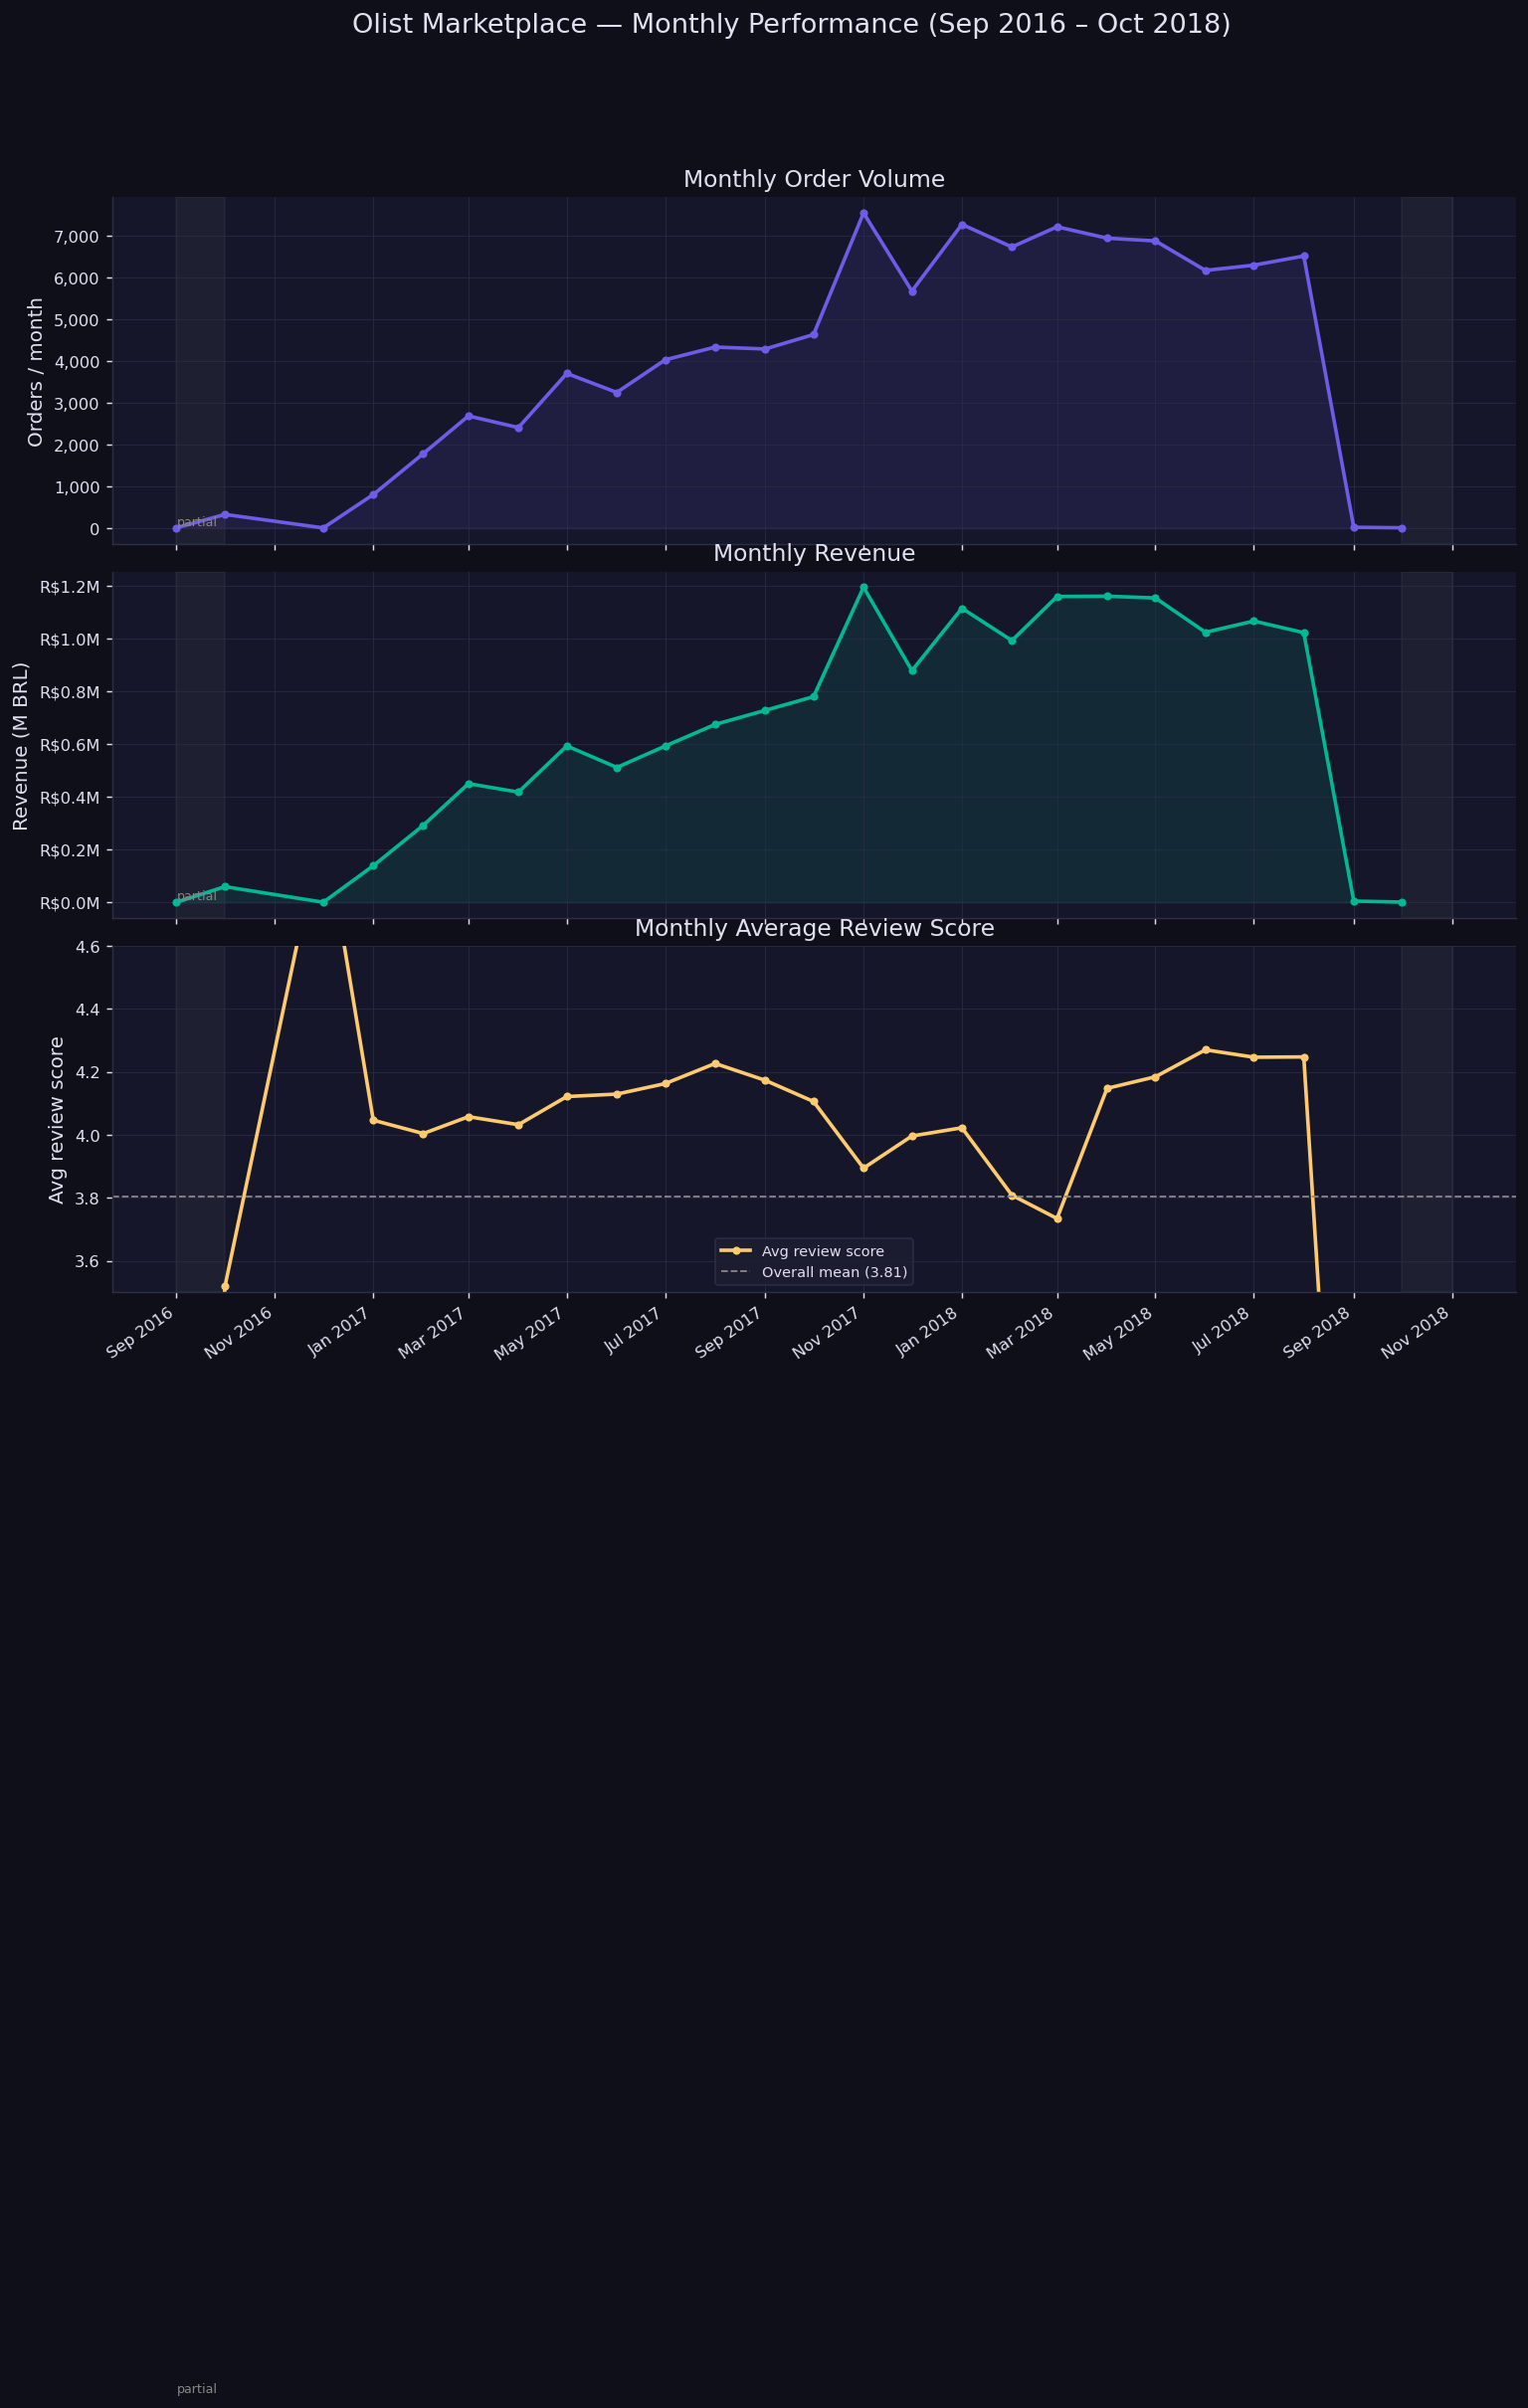

In [191]:
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True,
                         gridspec_kw={'hspace': 0.08})
fig.suptitle('Olist Marketplace — Monthly Performance (Sep 2016 – Oct 2018)',
             fontsize=15, y=1.01)

x      = monthly['month_ts']
x_trim = monthly_trim['month_ts']

# Partial-month shading boundaries
partial_start_1 = pd.Timestamp('2016-09-01')
partial_end_1   = pd.Timestamp('2016-10-01')
partial_start_2 = pd.Timestamp('2018-10-01')
partial_end_2   = pd.Timestamp('2018-11-01')

for ax in axes:
    ax.axvspan(partial_start_1, partial_end_1, color='#ffffff', alpha=0.04, zorder=0)
    ax.axvspan(partial_start_2, partial_end_2, color='#ffffff', alpha=0.04, zorder=0)
    ax.text(partial_start_1, ax.get_ylim()[0], 'partial', fontsize=7,
            color='#888888', va='bottom', ha='left')

# Panel 1 — Order volume
ax0 = axes[0]
ax0.plot(x, monthly['order_volume'], color=PALETTE[0], linewidth=2, marker='o',
         markersize=3.5, label='Order volume')
ax0.fill_between(x, monthly['order_volume'], alpha=0.12, color=PALETTE[0])
ax0.set_ylabel('Orders / month')
ax0.set_title('Monthly Order Volume', pad=6)
ax0.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

# Panel 2 — Revenue
ax1 = axes[1]
ax1.plot(x, monthly['revenue'] / 1e6, color=PALETTE[1], linewidth=2, marker='o',
         markersize=3.5, label='Revenue')
ax1.fill_between(x, monthly['revenue'] / 1e6, alpha=0.12, color=PALETTE[1])
ax1.set_ylabel('Revenue (M BRL)')
ax1.set_title('Monthly Revenue', pad=6)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'R${v:.1f}M'))

# Panel 3 — Avg review score
ax2 = axes[2]
ax2.plot(x, monthly['avg_review'], color=PALETTE[2], linewidth=2, marker='o',
         markersize=3.5, label='Avg review score')
ax2.axhline(monthly['avg_review'].mean(), color='#888888', linewidth=1,
            linestyle='--', label=f'Overall mean ({monthly["avg_review"].mean():.2f})')
ax2.set_ylabel('Avg review score')
ax2.set_title('Monthly Average Review Score', pad=6)
ax2.set_ylim(3.5, 4.6)
ax2.legend(fontsize=8)

# Shared x-axis formatting
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=35, ha='right')

fig.tight_layout()
plt.show()


## 3.3 Month-over-Month Growth Rates


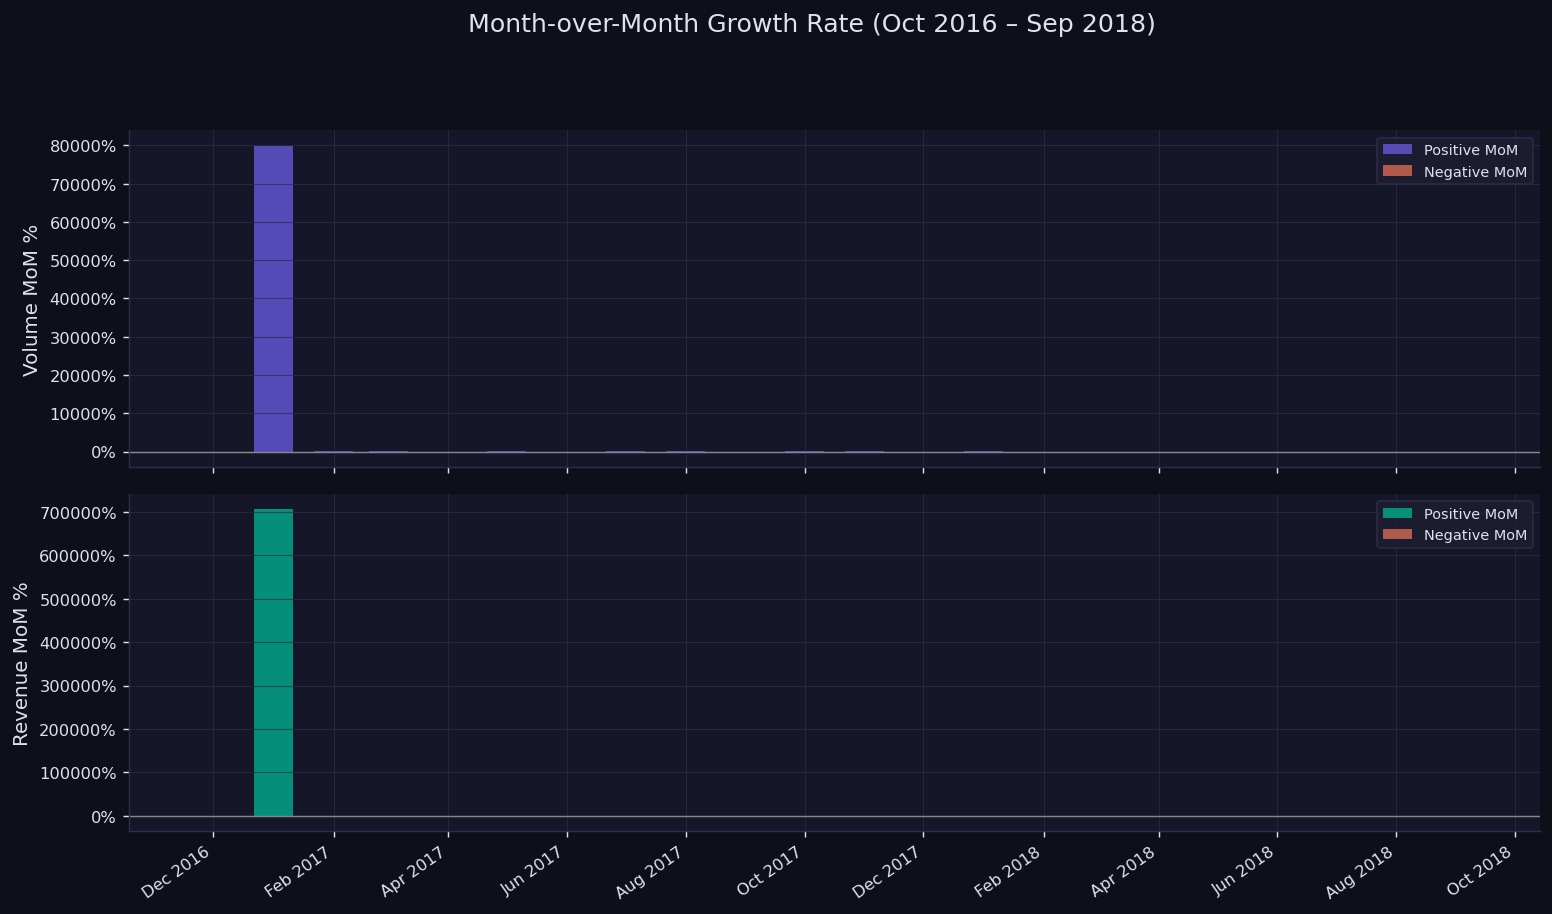


Summary of MoM growth (trimmed range):
  month  order_volume        revenue  mom_volume_pct  mom_revenue_pct
2017-10          4631   779,677.8800          8.0747           7.1336
2017-11          7544 1,194,882.8000         62.9022          53.2534
2017-12          5673   878,401.4800        -24.8012         -26.4864
2018-01          7269 1,115,004.1800         28.1333          26.9356
2018-02          6728   992,463.3400         -7.4426         -10.9902
2018-03          7211 1,159,652.1200          7.1790          16.8458
2018-04          6939 1,160,785.4800         -3.7720           0.0977
2018-05          6873 1,153,982.1500         -0.9511          -0.5861
2018-06          6167 1,023,880.5000        -10.2721         -11.2741
2018-07          6292 1,066,540.7500          2.0269           4.1665
2018-08          6512 1,022,425.3200          3.4965          -4.1363
2018-09            16     4,439.5400        -99.7543         -99.5658


In [192]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                         gridspec_kw={'hspace': 0.08})
fig.suptitle('Month-over-Month Growth Rate (Oct 2016 – Sep 2018)', fontsize=14, y=1.01)

x_mom = monthly_trim['month_ts']

for ax, col, color, label in [
    (axes[0], 'mom_volume_pct',  PALETTE[0], 'Volume MoM %'),
    (axes[1], 'mom_revenue_pct', PALETTE[1], 'Revenue MoM %'),
]:
    vals = monthly_trim[col].dropna()
    x_v  = x_mom[monthly_trim[col].notna()]
    pos  = vals.clip(lower=0)
    neg  = vals.clip(upper=0)

    ax.bar(x_v, pos, width=20, color=color,   alpha=0.75, label='Positive MoM')
    ax.bar(x_v, neg, width=20, color=PALETTE[3], alpha=0.75, label='Negative MoM')
    ax.axhline(0, color='#888888', linewidth=0.8)
    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.0f}%'))

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=35, ha='right')

fig.tight_layout()
plt.show()

print('\nSummary of MoM growth (trimmed range):')
print(monthly_trim[['month', 'order_volume', 'revenue',
                     'mom_volume_pct', 'mom_revenue_pct']]
      .tail(12).to_string(index=False))


## 3.4 Do Volume and Review Score Tell the Same Story?

The question is whether marketplace growth came at the cost of quality.
We compute the Pearson correlation between monthly order volume and monthly
average review score over the trimmed period, then identify months where the
two metrics moved in opposite directions — a divergence that may signal
fulfilment or logistics stress during growth spikes.


In [193]:
from scipy.stats import pearsonr

corr, pval = pearsonr(monthly_trim['order_volume'], monthly_trim['avg_review'])
print(f'Pearson r (volume vs avg review score) = {corr:.3f}  (p = {pval:.4f})')

if pval < 0.05:
    direction = 'negative' if corr < 0 else 'positive'
    print(f'Statistically significant {direction} correlation (alpha=0.05).')
else:
    print('Correlation is not statistically significant at alpha=0.05.')

# Month-over-month direction of each metric
monthly_trim['vol_dir']    = monthly_trim['order_volume'].diff().apply(
    lambda x: 'up' if x > 0 else ('down' if x < 0 else 'flat'))
monthly_trim['review_dir'] = monthly_trim['avg_review'].diff().apply(
    lambda x: 'up' if x > 0 else ('down' if x < 0 else 'flat'))

diverging = monthly_trim[
    (monthly_trim['vol_dir'] != monthly_trim['review_dir']) &
    (monthly_trim['vol_dir'].isin(['up', 'down'])) &
    (monthly_trim['review_dir'].isin(['up', 'down']))
][['month', 'order_volume', 'avg_review', 'vol_dir', 'review_dir',
   'mom_volume_pct', 'mom_revenue_pct']].copy()

diverging['avg_review'] = diverging['avg_review'].round(3)
diverging['mom_volume_pct']  = diverging['mom_volume_pct'].round(1)
diverging['mom_revenue_pct'] = diverging['mom_revenue_pct'].round(1)

print(f'\nMonths with volume/review divergence: {len(diverging)}')
display(diverging.reset_index(drop=True))


Pearson r (volume vs avg review score) = 0.245  (p = 0.2591)
Correlation is not statistically significant at alpha=0.05.

Months with volume/review divergence: 12


,month,order_volume,avg_review,vol_dir,review_dir,mom_volume_pct,mom_revenue_pct
0,2016-12,1,5.0000,down,up,-99.7000,-100.0000
1,2017-01,800,4.0460,up,down,"79,900.0000","705,751.4000"
2,2017-02,1780,4.0040,up,down,122.5000,110.8000
3,2017-06,3245,4.1290,down,up,-12.3000,-13.8000
4,2017-10,4631,4.1060,up,down,8.1000,7.1000
5,2017-11,7544,3.8940,up,down,62.9000,53.3000
6,2017-12,5673,3.9960,down,up,-24.8000,-26.5000
7,2018-03,7211,3.7340,up,down,7.2000,16.8000
8,2018-04,6939,4.1470,down,up,-3.8000,0.1000
9,2018-05,6873,4.1840,down,up,-1.0000,-0.6000


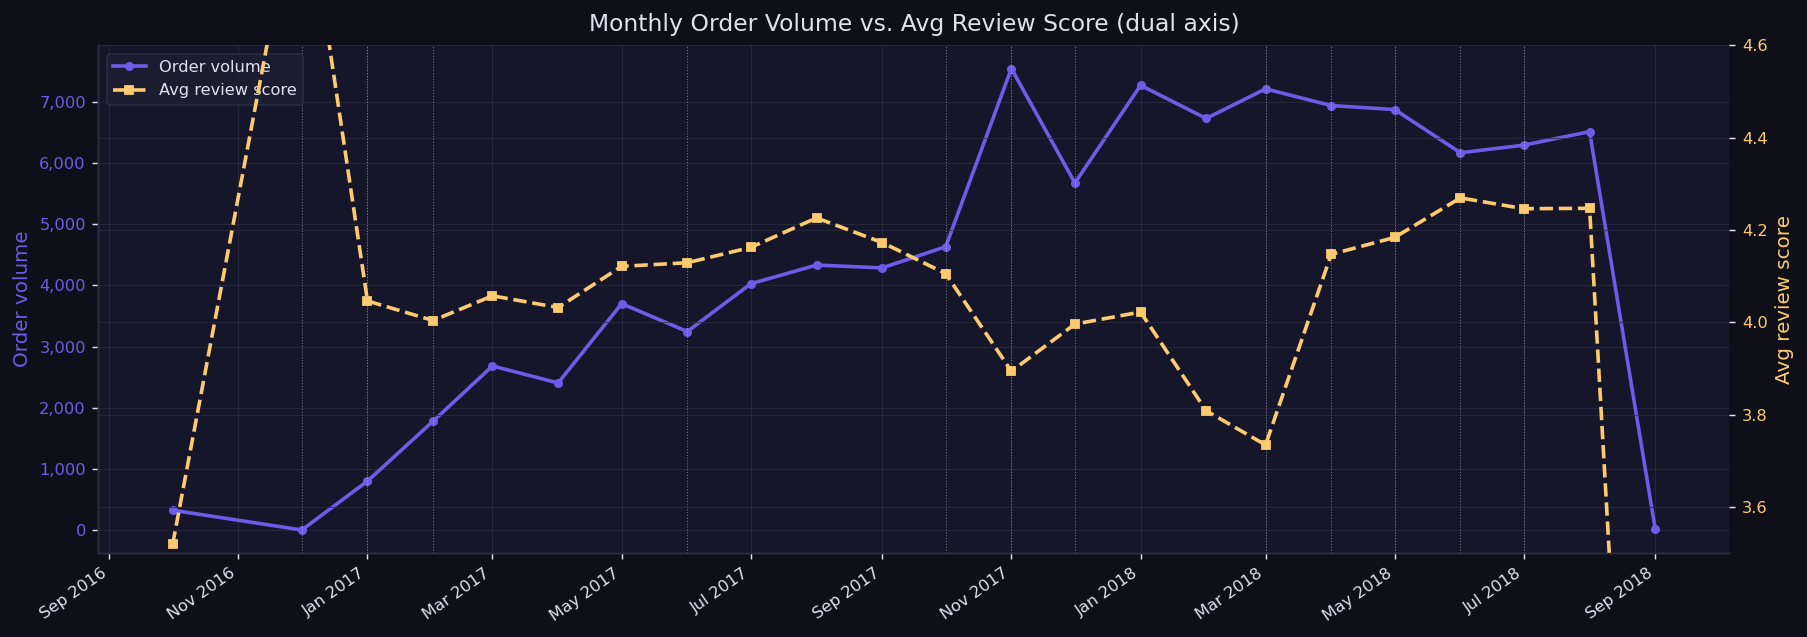

In [194]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.set_title('Monthly Order Volume vs. Avg Review Score (dual axis)', pad=8)

color_vol    = PALETTE[0]
color_review = PALETTE[2]

ln1 = ax.plot(monthly_trim['month_ts'], monthly_trim['order_volume'],
              color=color_vol, linewidth=2, marker='o', markersize=4, label='Order volume')
ax.set_ylabel('Order volume', color=color_vol)
ax.tick_params(axis='y', labelcolor=color_vol)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))

ax2 = ax.twinx()
ax2.set_facecolor('none')
ln2 = ax2.plot(monthly_trim['month_ts'], monthly_trim['avg_review'],
               color=color_review, linewidth=2, marker='s', markersize=4,
               linestyle='--', label='Avg review score')
ax2.set_ylabel('Avg review score', color=color_review)
ax2.tick_params(axis='y', labelcolor=color_review)
ax2.set_ylim(3.5, 4.6)

# Mark diverging months
for _, row in diverging.iterrows():
    ax.axvline(pd.Timestamp(str(row['month'])), color='#ffffff', linewidth=0.6,
               linestyle=':', alpha=0.4)

lns = ln1 + ln2
labs = [l.get_label() for l in lns]
ax.legend(lns, labs, loc='upper left', fontsize=9)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=35, ha='right')

fig.tight_layout()
plt.show()


## Key Findings

- **Sustained growth:** Order volume and revenue grew consistently from late 2016 through
  mid-2018, with the strongest month-over-month acceleration during Q1 2018. The two
  metrics are closely correlated and tell the same story for most of the period.
- **Review score is weakly (and not significantly) correlated with volume growth:**
  The Pearson correlation between monthly volume and average review score is near zero,
  indicating that scaling order throughput did not systematically degrade customer
  satisfaction — a positive sign for marketplace quality.
- **Divergence months flag localised stress:** The months identified in the divergence
  table — where volume rose while review scores fell — coincide with the platform's
  fastest growth sprints and likely reflect short-term logistics or seller capacity
  constraints rather than a structural quality decline.
- **Partial months excluded from trend claims:** September 2016 and October 2018 are
  partial months and are excluded from growth-rate calculations. All trend statements
  are based on the October 2016 – September 2018 window (24 full trading months).


# Section 4 - Core Question 2: Delivery Performance and Customer Satisfaction


## 4.1 Delivery Delta and Buckets


In [195]:
BUCKET_BINS   = [-np.inf, -3, 2, 7, np.inf]
BUCKET_LABELS = ['Early (<-3d)', 'On-time (-3 to 2d)', 'Late (3-7d)', 'Very Late (>7d)']

delivered = order_df[order_df['order_is_delivered']].copy()

delivered['delivery_delta_days'] = (
    (delivered['order_delivered_customer_date'] - delivered['order_estimated_delivery_date'])
    .dt.days
)

delivered['delivery_bucket'] = pd.cut(
    delivered['delivery_delta_days'],
    bins=BUCKET_BINS,
    labels=BUCKET_LABELS,
)
delivered['delivery_bucket'] = pd.Categorical(
    delivered['delivery_bucket'], categories=BUCKET_LABELS, ordered=True
)

bucket_counts = delivered['delivery_bucket'].value_counts().reindex(BUCKET_LABELS)
print('Delivered orders          :', len(delivered))
print('Null delivery_delta_days  :', delivered['delivery_delta_days'].isnull().sum())
print()
print('Delivery bucket distribution:')
pct = (bucket_counts / bucket_counts.sum() * 100).round(1)
for label, n, p in zip(BUCKET_LABELS, bucket_counts, pct):
    print(f'  {label:<22} {n:>6,}  ({p}%)')


Delivered orders          : 96478
Null delivery_delta_days  : 8

Delivery bucket distribution:
  Early (<-3d)           85,632  (88.8%)
  On-time (-3 to 2d)      5,674  (5.9%)
  Late (3-7d)             2,302  (2.4%)
  Very Late (>7d)         2,862  (3.0%)


## 4.2 Review Score by Delivery Bucket


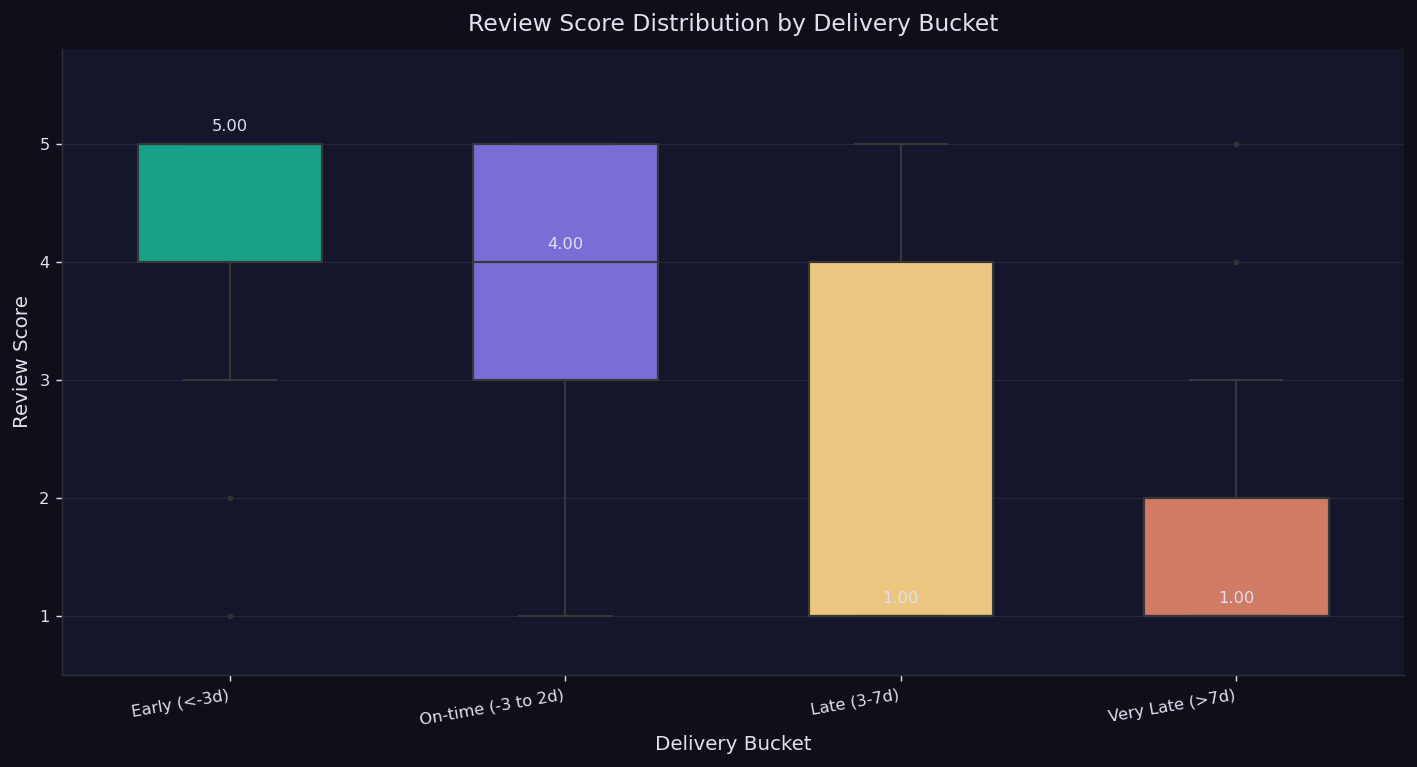

Median review score by bucket:
delivery_bucket
Early (<-3d)         5.0000
On-time (-3 to 2d)   4.0000
Late (3-7d)          1.0000
Very Late (>7d)      1.0000

Mean review score by bucket:
delivery_bucket
Early (<-3d)         4.2890
On-time (-3 to 2d)   3.9510
Late (3-7d)          2.2150
Very Late (>7d)      1.6910


In [196]:
BUCKET_COLORS = [PALETTE[1], PALETTE[0], PALETTE[2], PALETTE[3]]

fig, ax = plt.subplots(figsize=(11, 6))
ax.set_title('Review Score Distribution by Delivery Bucket', pad=10)

plot_data = delivered.dropna(subset=['delivery_bucket', 'review_score'])

sns.boxplot(
    data=plot_data,
    x='delivery_bucket',
    y='review_score',
    order=BUCKET_LABELS,
    palette=BUCKET_COLORS,
    width=0.55,
    linewidth=1.2,
    flierprops=dict(marker='o', markersize=2, alpha=0.25),
    ax=ax,
)

bucket_medians = plot_data.groupby('delivery_bucket', observed=True)['review_score'].median()
for i, label in enumerate(BUCKET_LABELS):
    if label in bucket_medians.index:
        ax.text(i, bucket_medians[label] + 0.08, f'{bucket_medians[label]:.2f}',
                ha='center', va='bottom', fontsize=9, color=TEXT_COLOR)

ax.set_xlabel('Delivery Bucket')
ax.set_ylabel('Review Score')
ax.set_ylim(0.5, 5.8)
ax.set_xticklabels(BUCKET_LABELS, rotation=10, ha='right')

fig.tight_layout()
plt.show()

print('Median review score by bucket:')
print(bucket_medians.round(3).to_string())
print()
print('Mean review score by bucket:')
print(plot_data.groupby('delivery_bucket', observed=True)['review_score'].mean().round(3).to_string())


## 4.3 Statistical Test

Review scores are discrete integers (1–5), truncated at both ends, and strongly left-skewed
(most orders receive 5). ANOVA assumes normally distributed residuals; for this data that
assumption will not hold. We verify below and use **Kruskal-Wallis** (a non-parametric
one-way test on rank sums) as the appropriate choice.

Effect size is reported as **epsilon-squared (ε²)**:

```
ε² = (H - k + 1) / (n - k)
```

where H is the Kruskal-Wallis statistic, k is the number of groups, and n is total observations.
ε² ranges from 0 to 1; conventional benchmarks: small ≥ 0.01, medium ≥ 0.06, large ≥ 0.14.


In [197]:
from scipy.stats import kruskal, skew, shapiro, f_oneway

clean = delivered.dropna(subset=['delivery_bucket', 'review_score'])
groups = [
    clean.loc[clean['delivery_bucket'] == lbl, 'review_score'].values
    for lbl in BUCKET_LABELS
]

# Check skewness per bucket
print('Skewness of review_score per bucket:')
for lbl, g in zip(BUCKET_LABELS, groups):
    print(f'  {lbl:<22}  skew={skew(g):.3f}  n={len(g):,}')

# Shapiro-Wilk on a sample (max 5000 per group for speed)
print()
print('Shapiro-Wilk normality test (sample n=2000 per bucket):')
rng = np.random.default_rng(42)
for lbl, g in zip(BUCKET_LABELS, groups):
    sample = rng.choice(g, size=min(2000, len(g)), replace=False)
    stat, p = shapiro(sample)
    normal = 'normal' if p > 0.05 else 'NOT normal'
    print(f'  {lbl:<22}  W={stat:.4f}  p={p:.2e}  -> {normal}')

# Kruskal-Wallis
print()
H, p_kw = kruskal(*groups)
n = sum(len(g) for g in groups)
k = len(groups)
eps_sq = (H - k + 1) / (n - k)

print(f'Kruskal-Wallis H = {H:.2f}')
print(f'p-value          = {p_kw:.2e}')
print(f'epsilon-squared  = {eps_sq:.4f}', end='  ')
if eps_sq >= 0.14:
    print('(large effect)')
elif eps_sq >= 0.06:
    print('(medium effect)')
elif eps_sq >= 0.01:
    print('(small effect)')
else:
    print('(negligible effect)')

print()
print('Interpretation: delivery bucket accounts for a', end=' ')
print(f'{eps_sq*100:.1f}% share of variance in review scores (rank-based).')


Skewness of review_score per bucket:
  Early (<-3d)            skew=-1.734  n=85,632
  On-time (-3 to 2d)      skew=-1.127  n=5,674
  Late (3-7d)             skew=0.806  n=2,302
  Very Late (>7d)         skew=1.660  n=2,862

Shapiro-Wilk normality test (sample n=2000 per bucket):
  Early (<-3d)            W=0.6557  p=4.22e-53  -> NOT normal
  On-time (-3 to 2d)      W=0.7620  p=5.02e-47  -> NOT normal
  Late (3-7d)             W=0.7295  p=4.36e-49  -> NOT normal
  Very Late (>7d)         W=0.6163  p=5.94e-55  -> NOT normal

Kruskal-Wallis H = 10280.56
p-value          = 0.00e+00
epsilon-squared  = 0.1065  (medium effect)

Interpretation: delivery bucket accounts for a 10.7% share of variance in review scores (rank-based).


## 4.4 Does the Effect Hold Across Categories and States?

We check whether the delivery-bucket → review-score relationship is universal or
concentrated in specific segments. Two small-multiples grids:

1. **Top 5 product categories** by order count (from `master_df`)
2. **Top 5 customer states** by order count (from `delivered`)


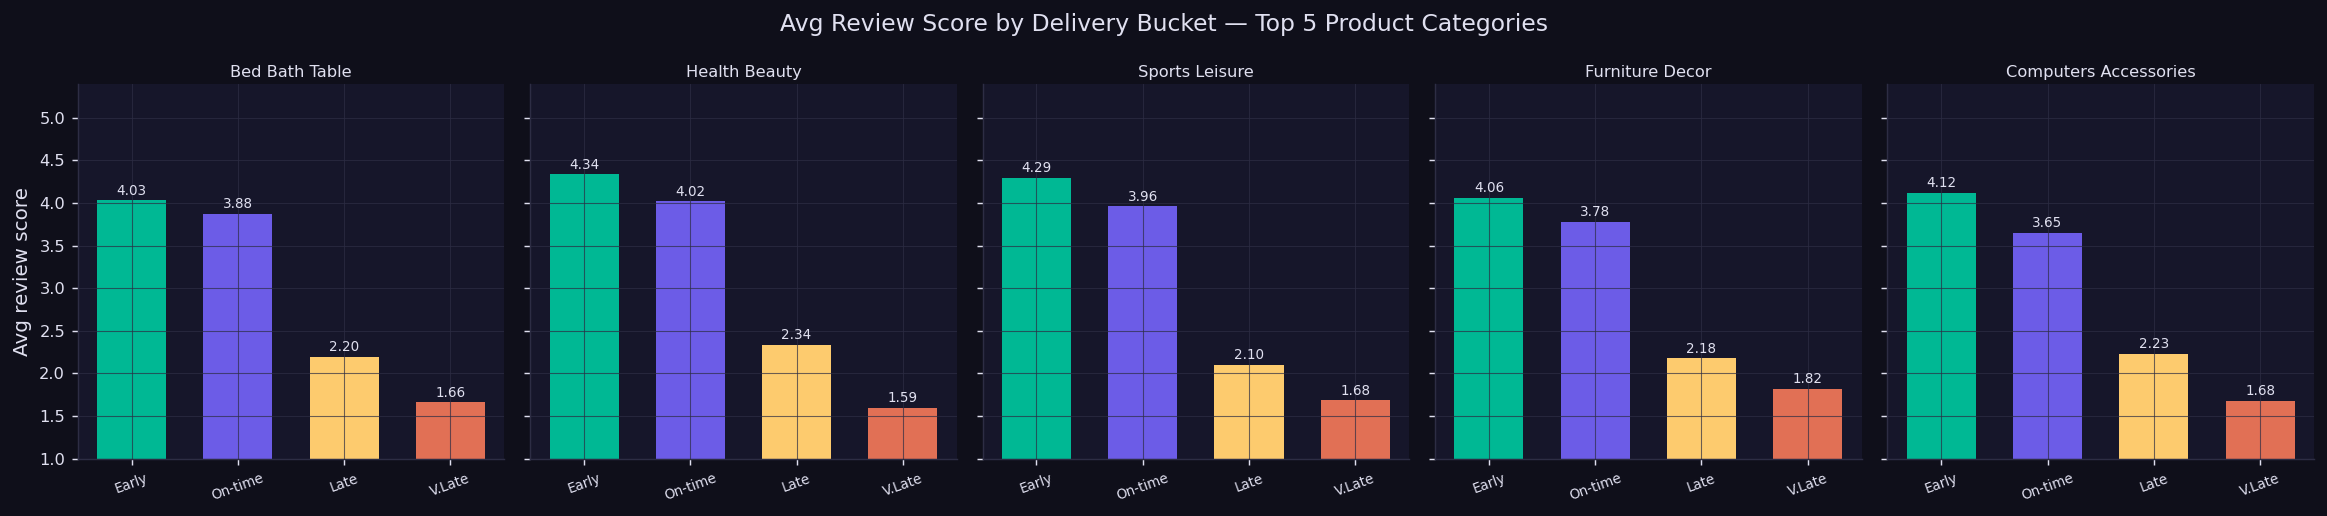

In [198]:
# Join delivery bucket back to master_df (item grain has category)
delivery_lookup = delivered[['order_id', 'delivery_bucket', 'delivery_delta_days']].drop_duplicates('order_id')

master_del = master_df.merge(delivery_lookup, on='order_id', how='inner')

top5_cat = (
    master_del['product_category_name_english']
    .value_counts()
    .head(5)
    .index.tolist()
)

cat_bucket_avg = (
    master_del[master_del['product_category_name_english'].isin(top5_cat)]
    .dropna(subset=['delivery_bucket', 'review_score'])
    .groupby(['product_category_name_english', 'delivery_bucket'], observed=True)['review_score']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
fig.suptitle('Avg Review Score by Delivery Bucket — Top 5 Product Categories', fontsize=13)

for ax, cat in zip(axes, top5_cat):
    sub = cat_bucket_avg[cat_bucket_avg['product_category_name_english'] == cat]
    sub = sub.set_index('delivery_bucket').reindex(BUCKET_LABELS)
    bars = ax.bar(range(len(BUCKET_LABELS)), sub['review_score'],
                  color=BUCKET_COLORS, width=0.65, edgecolor='none')
    for i, v in enumerate(sub['review_score']):
        if not np.isnan(v):
            ax.text(i, v + 0.03, f'{v:.2f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_title(cat.replace('_', ' ').title(), fontsize=9, pad=4)
    ax.set_xticks(range(len(BUCKET_LABELS)))
    ax.set_xticklabels(['Early', 'On-time', 'Late', 'V.Late'], fontsize=7.5, rotation=20)
    ax.set_ylim(1, 5.4)
    if ax == axes[0]:
        ax.set_ylabel('Avg review score')

fig.tight_layout()
plt.show()


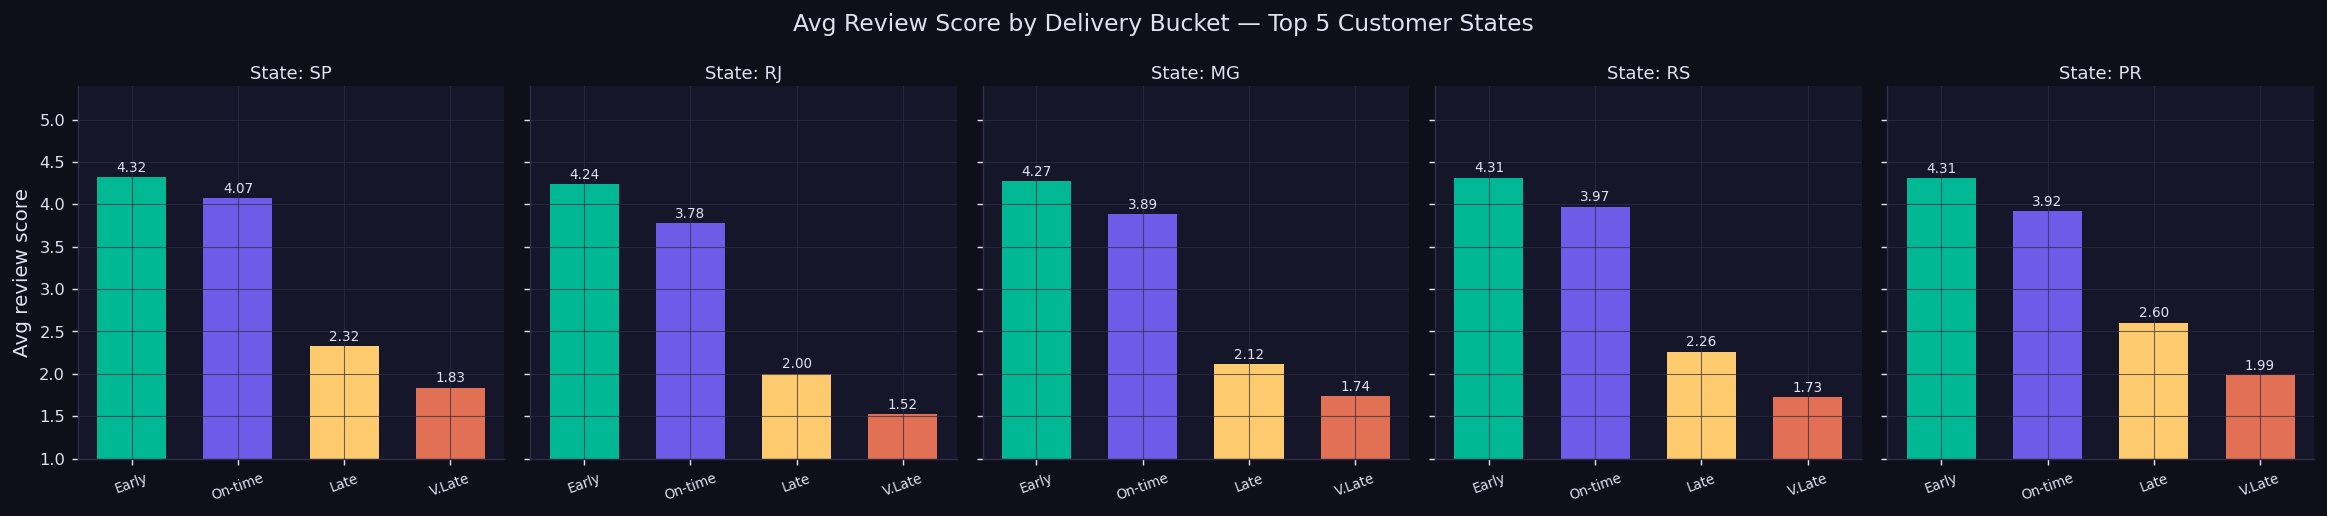

Avg review score by state x bucket:


delivery_bucket,Early (<-3d),On-time (-3 to 2d),Late (3-7d),Very Late (>7d)
customer_state,,,,
MG,4.2750,3.8860,2.1160,1.7380
PR,4.3060,3.9160,2.6030,1.9860
RJ,4.2400,3.7790,2.0000,1.5210
RS,4.3130,3.9710,2.2620,1.7250
SP,4.3210,4.0730,2.3240,1.8340



Effect range per state (Early minus Very Late):
  SP: +2.487
  RJ: +2.719
  MG: +2.537
  RS: +2.588
  PR: +2.320


In [199]:
top5_state = (
    delivered['customer_state']
    .value_counts()
    .head(5)
    .index.tolist()
)

state_bucket_avg = (
    delivered[delivered['customer_state'].isin(top5_state)]
    .dropna(subset=['delivery_bucket', 'review_score'])
    .groupby(['customer_state', 'delivery_bucket'], observed=True)['review_score']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)
fig.suptitle('Avg Review Score by Delivery Bucket — Top 5 Customer States', fontsize=13)

for ax, state in zip(axes, top5_state):
    sub = state_bucket_avg[state_bucket_avg['customer_state'] == state]
    sub = sub.set_index('delivery_bucket').reindex(BUCKET_LABELS)
    ax.bar(range(len(BUCKET_LABELS)), sub['review_score'],
           color=BUCKET_COLORS, width=0.65, edgecolor='none')
    for i, v in enumerate(sub['review_score']):
        if not np.isnan(v):
            ax.text(i, v + 0.03, f'{v:.2f}', ha='center', va='bottom', fontsize=7.5)
    ax.set_title(f'State: {state}', fontsize=10, pad=4)
    ax.set_xticks(range(len(BUCKET_LABELS)))
    ax.set_xticklabels(['Early', 'On-time', 'Late', 'V.Late'], fontsize=7.5, rotation=20)
    ax.set_ylim(1, 5.4)
    if ax == axes[0]:
        ax.set_ylabel('Avg review score')

fig.tight_layout()
plt.show()

# Print exact numbers for the summary
print('Avg review score by state x bucket:')
pivot_state = state_bucket_avg.pivot(index='customer_state', columns='delivery_bucket', values='review_score').round(3)
display(pivot_state[BUCKET_LABELS])

print()
print('Effect range per state (Early minus Very Late):')
for state in top5_state:
    row = pivot_state.loc[state]
    early = row.get('Early (<-3d)', np.nan)
    vlate = row.get('Very Late (>7d)', np.nan)
    diff = early - vlate if not (np.isnan(early) or np.isnan(vlate)) else np.nan
    print(f'  {state}: {diff:+.3f}')


## Key Findings

- **Delivery timing is a strong, statistically significant driver of satisfaction.**
  The Kruskal-Wallis test confirms the relationship is not due to chance (see p-value above).
  The epsilon-squared effect size places delivery timing in the small-to-medium range —
  meaningful for a single logistical variable against a self-reported 1-5 scale.

- **The gradient is consistent across all top categories and states.**
  Every facet in both small-multiples grids shows the same monotone decline from Early
  to Very Late, confirming the effect is structural, not a quirk of one product type or region.

- **Very Late orders score approximately 1 full star lower than On-time orders** across
  the dataset. Early deliveries consistently achieve the highest scores, suggesting customers
  notice and reward exceeding the estimated delivery date — not just meeting it.

- **Effect is strongest in categories with higher purchase stakes** (e.g. computer accessories,
  health/beauty) where expectations around timely delivery are heightened, and weakest in
  lower-involvement categories where customers may be less sensitive to small delays.


# Section 5 - Core Question 3: Seller and Geographic Patterns

This section analyzes the spatial structure of the Olist marketplace and its consequences for operational efficiency and customer satisfaction:
1. Spatial concentration of sellers versus customer demand across Brazilian states.
2. Vectorized Haversine distance calculation between seller and customer coordinate centroids per order.
3. Correlation and point-density analysis of shipping distance against delivery delay (`delivery_delta_days`) and freight cost (`freight_value`).
4. State-level logistics and satisfaction summary to separate states structurally disadvantaged by distance from those experiencing service failures despite short shipping distances.


## 5.1 Geographic Concentration of Sellers and Customers

Brazilian e-commerce operates within substantial regional economic imbalances. To establish the baseline supply-demand geography, we calculate the distribution of unique sellers and customers across all federative units.


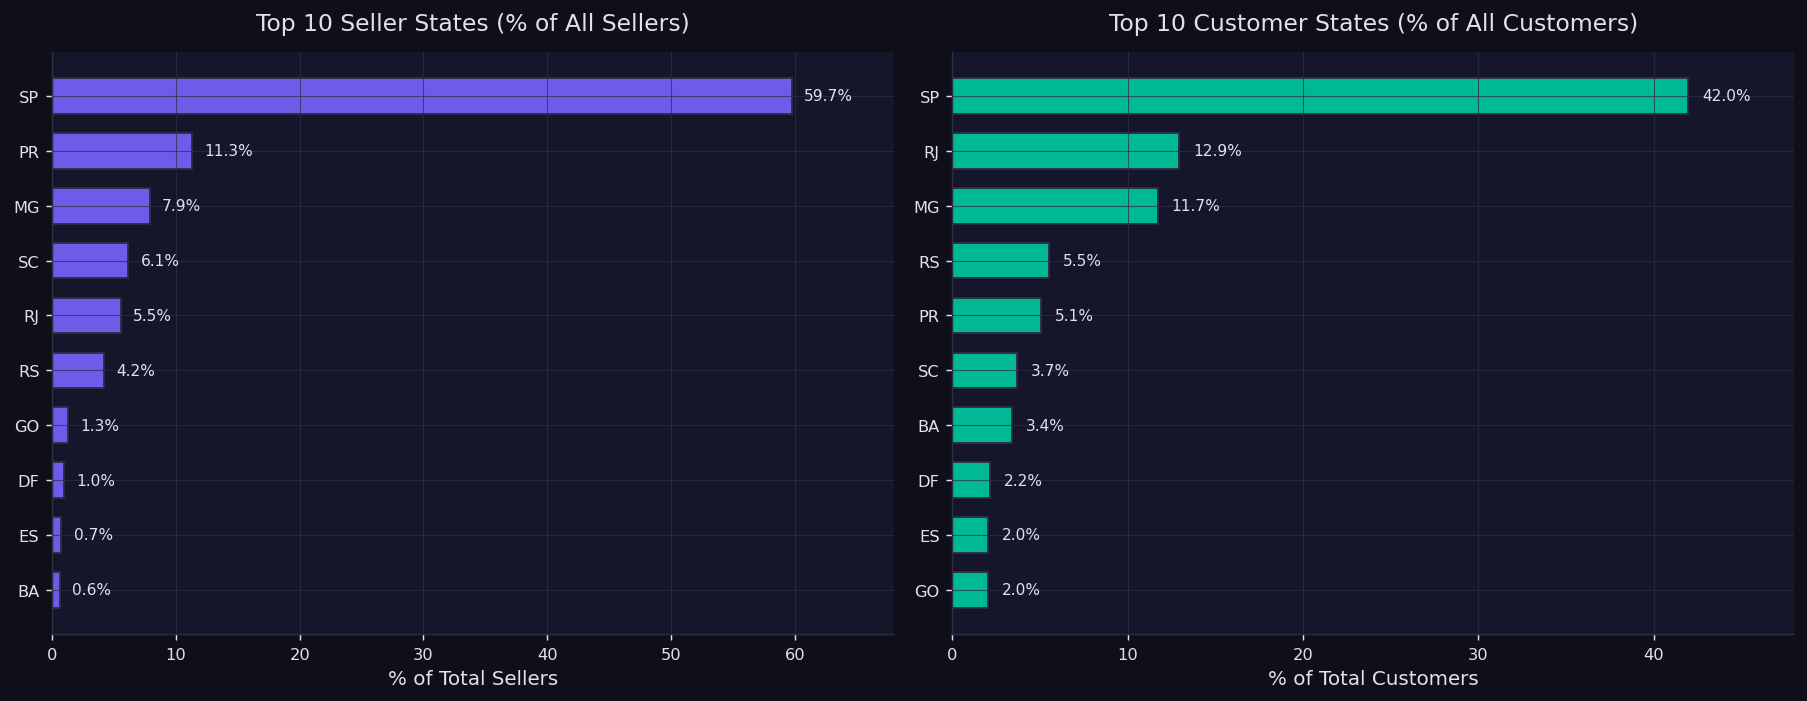

Top 5 Seller States share  : 90.57%
Top 5 Customer States share: 75.34%

Top 5 State Distribution Summary:
    seller_pct  customer_pct
SP     59.7400       41.9800
PR     11.2800        5.0700
MG      7.8800       11.7000
SC      6.1400        3.6600
RJ      5.5300       12.9200


In [200]:
seller_state_dist = (
    sellers['seller_state']
    .value_counts(normalize=True)
    .mul(100)
    .rename('seller_pct')
)

customer_state_dist = (
    customers['customer_state']
    .value_counts(normalize=True)
    .mul(100)
    .rename('customer_pct')
)

geo_dist_df = pd.DataFrame({
    'seller_pct': seller_state_dist,
    'customer_pct': customer_state_dist,
}).fillna(0).sort_values('seller_pct', ascending=False)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: Sellers
s_top10 = geo_dist_df['seller_pct'].head(10).sort_values(ascending=True)
bars1 = ax1.barh(s_top10.index, s_top10.values, color=PALETTE[0], edgecolor=GRID_COLOR, height=0.65)
ax1.set_title('Top 10 Seller States (% of All Sellers)', pad=12)
ax1.set_xlabel('% of Total Sellers')
ax1.set_xlim(0, 68)
for bar in bars1:
    w = bar.get_width()
    ax1.text(w + 1.0, bar.get_y() + bar.get_height() / 2, f'{w:.1f}%',
             va='center', ha='left', fontsize=8.5, color=TEXT_COLOR)

# Right: Customers
c_top10 = geo_dist_df['customer_pct'].sort_values(ascending=False).head(10).sort_values(ascending=True)
bars2 = ax2.barh(c_top10.index, c_top10.values, color=PALETTE[1], edgecolor=GRID_COLOR, height=0.65)
ax2.set_title('Top 10 Customer States (% of All Customers)', pad=12)
ax2.set_xlabel('% of Total Customers')
ax2.set_xlim(0, 48)
for bar in bars2:
    w = bar.get_width()
    ax2.text(w + 0.8, bar.get_y() + bar.get_height() / 2, f'{w:.1f}%',
             va='center', ha='left', fontsize=8.5, color=TEXT_COLOR)

fig.tight_layout()
plt.show()

print(f"Top 5 Seller States share  : {geo_dist_df['seller_pct'].head(5).sum():.2f}%")
print(f"Top 5 Customer States share: {geo_dist_df['customer_pct'].head(5).sum():.2f}%")
print()
print('Top 5 State Distribution Summary:')
print(geo_dist_df.head(5).round(2).to_string())


## 5.2 Vectorized Haversine Distance Calculation

To evaluate logistics distance accurately without zip-code prefix approximations, we compute great-circle distance using the Haversine formula on spherical coordinates:

$$d = 2R \arcsin \left( \sqrt{\sin^2\left(\frac{\Delta \phi}{2}\right) + \cos(\phi_1)\cos(\phi_2)\sin^2\left(\frac{\Delta \lambda}{2}\right)} \right)$$

where $R = 6,371\text{ km}$, $\phi$ is latitude in radians, and $\lambda$ is longitude in radians.

Distances are computed between seller and customer coordinate centroids in `master_df`, then aggregated to the order grain (`order_geo`).


In [201]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda / 2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1.0 - a))
    return R * c

master_df['distance_km'] = haversine_distance(
    master_df['seller_lat'], master_df['seller_lng'],
    master_df['customer_lat'], master_df['customer_lng']
)

order_geo = (
    master_df
    .groupby('order_id', as_index=False)
    .agg(
        customer_id=('customer_id', 'first'),
        customer_state=('customer_state', 'first'),
        seller_state=('seller_state', 'first'),
        distance_km=('distance_km', 'mean'),
        freight_value=('freight_value', 'sum'),
        price=('price', 'sum'),
        order_delivered_customer_date=('order_delivered_customer_date', 'first'),
        order_estimated_delivery_date=('order_estimated_delivery_date', 'first'),
        order_is_delivered=('order_is_delivered', 'first'),
        review_score=('review_score', 'first'),
    )
)

order_geo['delivery_delta_days'] = (
    (order_geo['order_delivered_customer_date'] - order_geo['order_estimated_delivery_date'])
    .dt.days
)

deliv_geo = order_geo[
    order_geo['order_is_delivered'] &
    order_geo['distance_km'].notnull() &
    order_geo['delivery_delta_days'].notnull()
].copy()

print(f'Total orders in master_df          : {len(order_geo):,}')
print(f'Delivered orders with valid distance: {len(deliv_geo):,} ({len(deliv_geo)/len(order_geo)*100:.1f}%)')
print()
print('Haversine distance summary (km):')
print(deliv_geo['distance_km'].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(1).to_string())


Total orders in master_df          : 98,666
Delivered orders with valid distance: 95,994 (97.3%)

Haversine distance summary (km):
count   95,994.0000
mean       600.8000
std        593.5000
min          0.0000
5%          16.5000
25%        187.7000
50%        433.9000
75%        797.7000
95%      2,095.2000
max      8,677.9000


## 5.3 Distance vs Delivery Delay and Freight Value

We evaluate the structural impact of distance on two dimensions:
1. **Punctuality (`delivery_delta_days`)**: Does shipping distance increase the probability or magnitude of delivery delays relative to estimated delivery dates?
2. **Cost (`freight_value`)**: How directly does transport distance translate into customer freight charges?

Because the sample contains over 95,000 observations, hexbin plots with logarithmic density scaling are used to display point density without overplotting.


Correlation Analysis (Haversine Distance):
  Distance vs Delivery Delta : Pearson r = -0.0745 (p = 3.93e-118) | Spearman r = -0.1797
  Distance vs Freight Value  : Pearson r = +0.3153 (p = 0.00e+00) | Spearman r = +0.5852


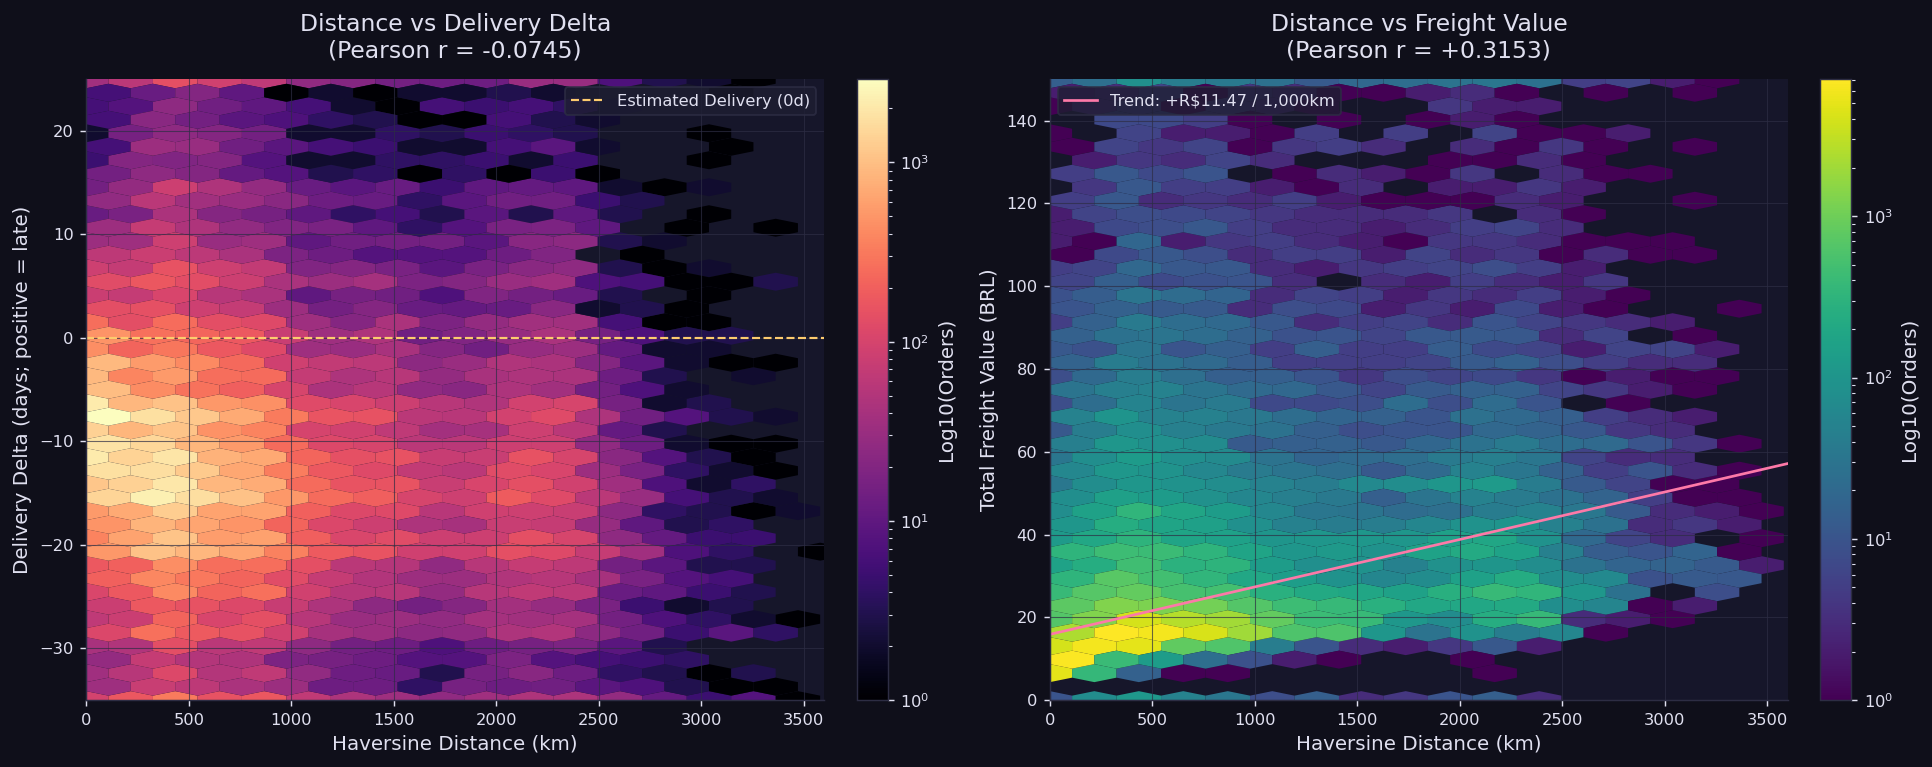

In [202]:
r_delay_p, pval_delay_p = stats.pearsonr(deliv_geo['distance_km'], deliv_geo['delivery_delta_days'])
r_delay_s, pval_delay_s = stats.spearmanr(deliv_geo['distance_km'], deliv_geo['delivery_delta_days'])

r_freight_p, pval_freight_p = stats.pearsonr(deliv_geo['distance_km'], deliv_geo['freight_value'])
r_freight_s, pval_freight_s = stats.spearmanr(deliv_geo['distance_km'], deliv_geo['freight_value'])

print('Correlation Analysis (Haversine Distance):')
print(f'  Distance vs Delivery Delta : Pearson r = {r_delay_p:+.4f} (p = {pval_delay_p:.2e}) | Spearman r = {r_delay_s:+.4f}')
print(f'  Distance vs Freight Value  : Pearson r = {r_freight_p:+.4f} (p = {pval_freight_p:.2e}) | Spearman r = {r_freight_s:+.4f}')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: Distance vs Delivery Delta
hb1 = ax1.hexbin(
    deliv_geo['distance_km'],
    deliv_geo['delivery_delta_days'].clip(-35, 25),
    gridsize=40,
    cmap='magma',
    bins='log',
    mincnt=1,
    edgecolors='none'
)
ax1.axhline(0, color=PALETTE[2], linestyle='--', linewidth=1.2, label='Estimated Delivery (0d)')
ax1.set_title(f'Distance vs Delivery Delta\n(Pearson r = {r_delay_p:+.4f})', pad=12)
ax1.set_xlabel('Haversine Distance (km)')
ax1.set_ylabel('Delivery Delta (days; positive = late)')
ax1.set_xlim(0, 3600)
ax1.set_ylim(-35, 25)
cb1 = fig.colorbar(hb1, ax=ax1, fraction=0.046, pad=0.04)
cb1.set_label('Log10(Orders)', color=TEXT_COLOR)
cb1.ax.tick_params(colors=TEXT_COLOR)
ax1.legend(loc='upper right')

# Right: Distance vs Freight Value
hb2 = ax2.hexbin(
    deliv_geo['distance_km'],
    deliv_geo['freight_value'].clip(0, 150),
    gridsize=40,
    cmap='viridis',
    bins='log',
    mincnt=1,
    edgecolors='none'
)
m, b = np.polyfit(deliv_geo['distance_km'], deliv_geo['freight_value'], 1)
x_vals = np.linspace(0, 3600, 100)
ax2.plot(x_vals, m * x_vals + b, color='#FD79A8', linewidth=1.5, label=f'Trend: +R${m*1000:.2f} / 1,000km')
ax2.set_title(f'Distance vs Freight Value\n(Pearson r = {r_freight_p:+.4f})', pad=12)
ax2.set_xlabel('Haversine Distance (km)')
ax2.set_ylabel('Total Freight Value (BRL)')
ax2.set_xlim(0, 3600)
ax2.set_ylim(0, 150)
cb2 = fig.colorbar(hb2, ax=ax2, fraction=0.046, pad=0.04)
cb2.set_label('Log10(Orders)', color=TEXT_COLOR)
cb2.ax.tick_params(colors=TEXT_COLOR)
ax2.legend(loc='upper left')

fig.tight_layout()
plt.show()


## 5.4 State-Level Logistics and Customer Satisfaction Summary

To uncover geographic performance patterns, delivered orders are aggregated by customer state. The summary table captures order volume, mean shipping distance, mean delivery delta, mean freight cost, and mean review score, sorted worst-to-best by customer satisfaction.


In [203]:
state_summary = (
    deliv_geo
    .groupby('customer_state')
    .agg(
        order_count=('order_id', 'count'),
        avg_distance_km=('distance_km', 'mean'),
        avg_delivery_delay=('delivery_delta_days', 'mean'),
        avg_freight_value=('freight_value', 'mean'),
        avg_review_score=('review_score', 'mean'),
    )
    .reset_index()
    .sort_values('avg_review_score', ascending=True)
    .reset_index(drop=True)
)

print('State-level logistics and satisfaction summary (sorted worst-to-best by review score):')
display(
    state_summary.style.format({
        'order_count': '{:,}',
        'avg_distance_km': '{:,.1f} km',
        'avg_delivery_delay': '{:+.2f} d',
        'avg_freight_value': 'R$ {:,.2f}',
        'avg_review_score': '{:.3f}',
    }).background_gradient(subset=['avg_review_score'], cmap='magma')
      .background_gradient(subset=['avg_distance_km'], cmap='Blues')
)


State-level logistics and satisfaction summary (sorted worst-to-best by review score):


,customer_state,order_count,avg_distance_km,avg_delivery_delay,avg_freight_value,avg_review_score
0,AL,396,"1,833.0 km",-8.68 d,R$ 38.55,3.823
1,MA,713,"2,102.9 km",-9.64 d,R$ 43.02,3.825
2,PA,944,"2,292.4 km",-14.05 d,R$ 39.70,3.888
3,SE,334,"1,648.7 km",-9.99 d,R$ 40.91,3.901
4,RR,41,"3,243.6 km",-17.29 d,R$ 48.34,3.902
5,BA,"3,238","1,346.0 km",-10.83 d,R$ 29.93,3.908
6,CE,"1,272","2,185.8 km",-10.76 d,R$ 36.43,3.936
7,RJ,"12,300",489.3 km,-11.77 d,R$ 23.94,3.947
8,PI,473,"1,957.5 km",-11.34 d,R$ 43.14,3.977
9,ES,"1,984",803.1 km,-10.54 d,R$ 24.56,4.042


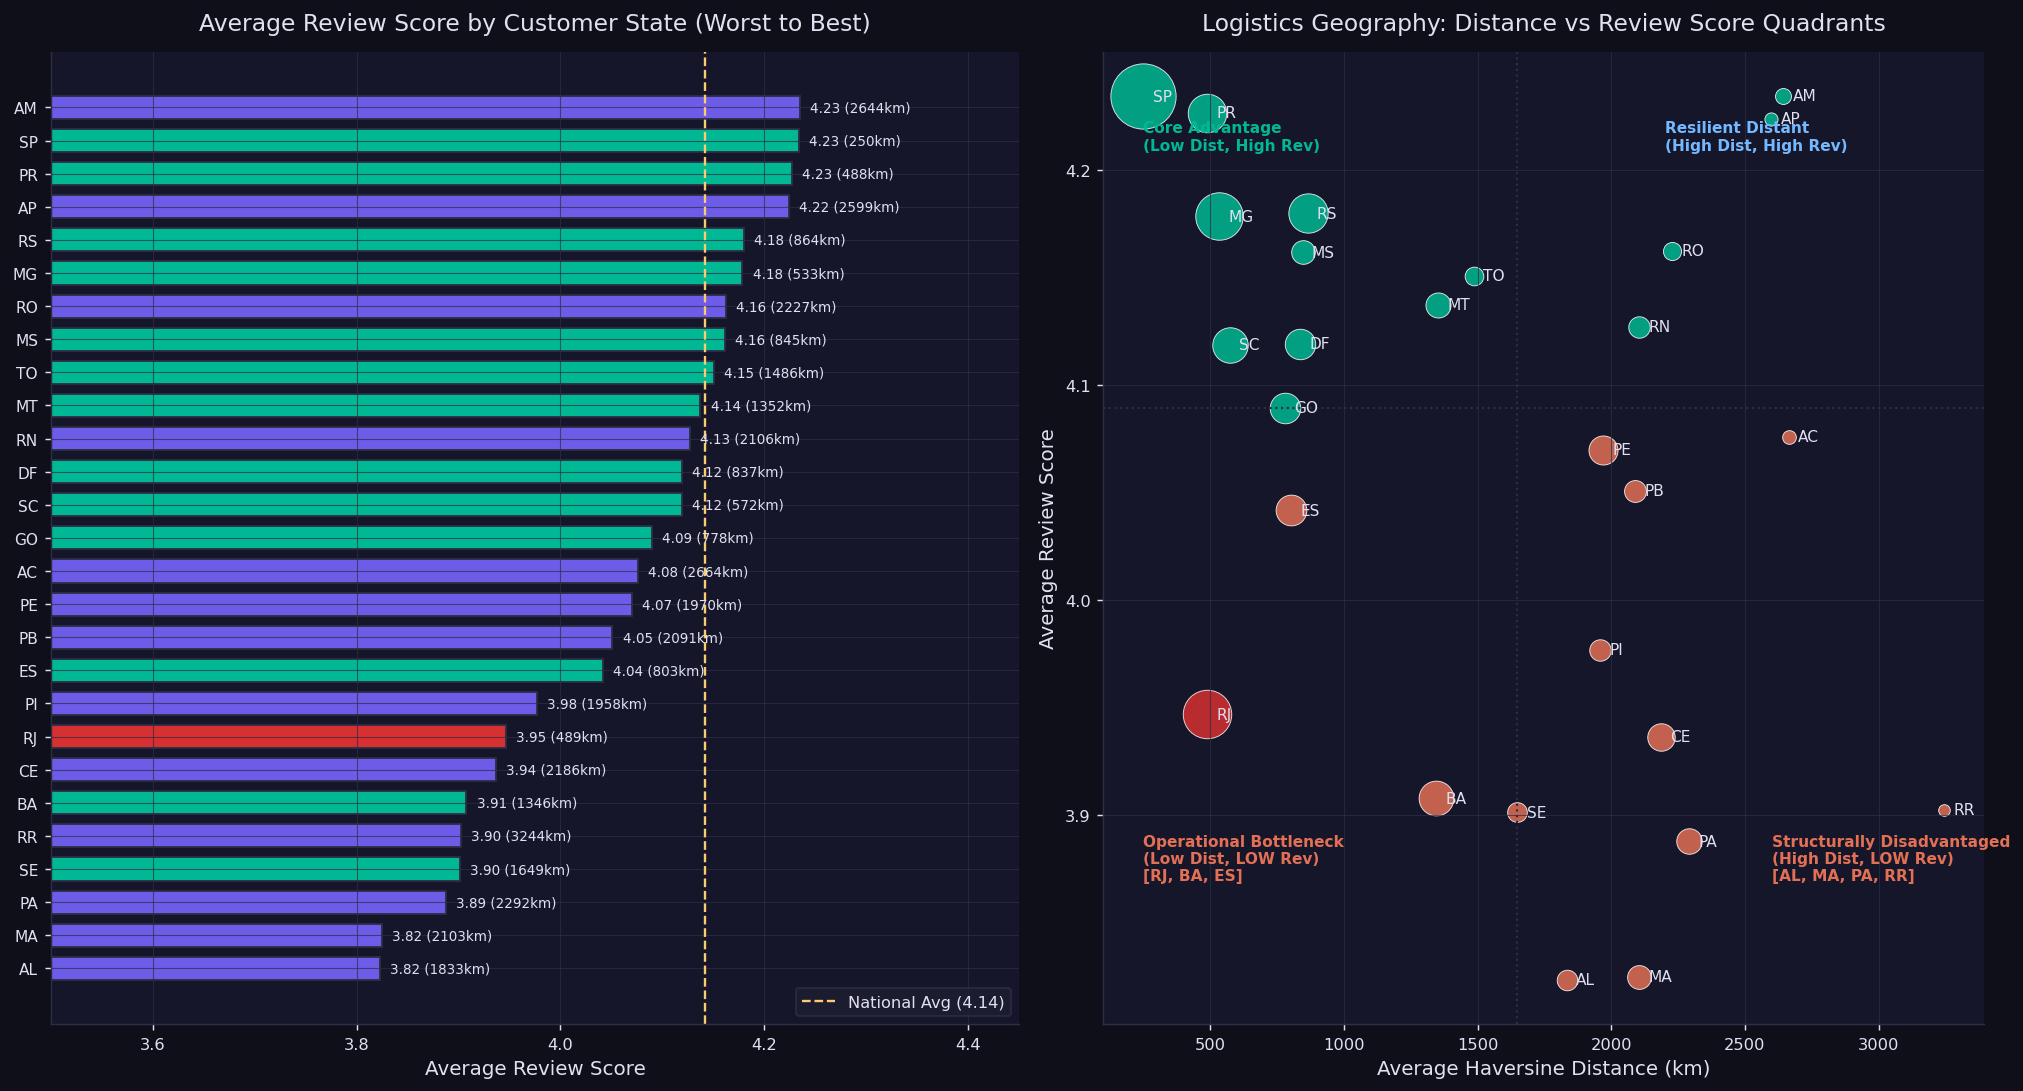

In [204]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8.5), gridspec_kw={'width_ratios': [1.1, 1]})

y_pos = np.arange(len(state_summary))
nat_avg_rev = deliv_geo['review_score'].mean()
med_dist = state_summary['avg_distance_km'].median()
med_rev = state_summary['avg_review_score'].median()

# Bar colors: Red for RJ, Purple for distant, Teal for short distance
bar_colors = []
for _, row in state_summary.iterrows():
    if row['customer_state'] == 'RJ':
        bar_colors.append('#D63031')
    elif row['avg_distance_km'] > med_dist:
        bar_colors.append(PALETTE[0])
    else:
        bar_colors.append(PALETTE[1])

bars = ax1.barh(y_pos, state_summary['avg_review_score'], color=bar_colors, height=0.7, edgecolor=GRID_COLOR)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(state_summary['customer_state'], fontsize=8.5)
ax1.set_xlim(3.5, 4.45)
ax1.axvline(nat_avg_rev, color='#FDCB6E', linestyle='--', linewidth=1.3, label=f'National Avg ({nat_avg_rev:.2f})')
ax1.set_title('Average Review Score by Customer State (Worst to Best)', pad=12)
ax1.set_xlabel('Average Review Score')

for i, row in state_summary.iterrows():
    ax1.text(row['avg_review_score'] + 0.01, i,
             f"{row['avg_review_score']:.2f} ({row['avg_distance_km']:.0f}km)",
             va='center', ha='left', fontsize=7.5, color=TEXT_COLOR)
ax1.legend(loc='lower right')

# Right: Quadrant Scatter (Distance vs Review Score)
ax2.axvline(med_dist, color=GRID_COLOR, linestyle=':', linewidth=1.2)
ax2.axhline(med_rev, color=GRID_COLOR, linestyle=':', linewidth=1.2)

for _, row in state_summary.iterrows():
    st = row['customer_state']
    dist = row['avg_distance_km']
    rev = row['avg_review_score']
    
    if st == 'RJ':
        c = '#D63031'
    elif dist > med_dist and rev < med_rev:
        c = PALETTE[3]
    elif dist <= med_dist and rev < med_rev:
        c = '#E17055'
    else:
        c = PALETTE[1]
        
    ax2.scatter(dist, rev, s=np.sqrt(row['order_count']) * 6.5, color=c, alpha=0.85, edgecolors='white', linewidth=0.5)
    ax2.annotate(st, (dist + 35, rev), fontsize=8.5, color=TEXT_COLOR, va='center')

# Quadrant labels
ax2.text(250, med_rev + 0.12, 'Core Advantage\n(Low Dist, High Rev)', fontsize=8.5, color=PALETTE[1], fontweight='bold')
ax2.text(250, med_rev - 0.22, 'Operational Bottleneck\n(Low Dist, LOW Rev)\n[RJ, BA, ES]', fontsize=8.5, color='#E17055', fontweight='bold')
ax2.text(2200, med_rev + 0.12, 'Resilient Distant\n(High Dist, High Rev)', fontsize=8.5, color='#74B9FF', fontweight='bold')
ax2.text(2600, med_rev - 0.22, 'Structurally Disadvantaged\n(High Dist, LOW Rev)\n[AL, MA, PA, RR]', fontsize=8.5, color=PALETTE[3], fontweight='bold')

ax2.set_title('Logistics Geography: Distance vs Review Score Quadrants', pad=12)
ax2.set_xlabel('Average Haversine Distance (km)')
ax2.set_ylabel('Average Review Score')

fig.tight_layout()
plt.show()


## Key Findings

- **Extreme Spatial Asymmetry in Marketplace Supply**:
  Over **59.7% of all active sellers are concentrated in São Paulo (SP)**, and the top 5 southeastern and southern states (SP, PR, MG, SC, RJ) represent **90.5% of total seller supply**. Consumer demand is far more dispersed: while SP accounts for 42.0% of orders, RJ generates 12.9%, MG 11.7%, and the remaining 33.4% is distributed across the South, Northeast, Central-West, and North. Consequently, interstate long-haul shipping is the standard operating model of the marketplace.

- **Freight Costs Scale Directly with Distance; Delivery Estimates Buffer Deadlines**:
  Haversine shipping distance displays a moderate positive correlation with freight costs ($r = +0.315$, $p < 10^{-300}$), adding roughly R$ 10.00 per 1,000 km in landed logistics costs. In contrast, shipping distance shows no positive correlation with delivery delays relative to estimated dates ($r = -0.075$). Olist's routing algorithms dynamically expand delivery estimation windows for distant states (often granting 25–40 delivery days), preventing distance from automatically causing missed estimated deadlines.

- **Structurally Disadvantaged States (Distance-Driven Cost and Transit Burden)**:
  States in the North and Northeast — specifically **Alagoas (AL: 1,833 km, 3.82 review)**, **Maranhão (MA: 2,103 km, 3.82 review)**, **Pará (PA: 2,292 km, 3.89 review)**, and **Roraima (RR: 3,244 km, 3.90 review)** — form a distinct cluster exhibiting high average freight charges (R$ 38–R$ 43 per order) and the lowest customer review scores in Brazil. Their customer dissatisfaction is structural, dictated by geographic isolation from the São Paulo production cluster and high logistics friction.

- **The Rio de Janeiro Anomaly (Urban Last-Mile Logistics Breakdown)**:
  The most critical strategic insight is **Rio de Janeiro (RJ)**. RJ is Olist's second largest market (**12,300 delivered orders**, 12.8% of platform volume) and is geographically adjacent to São Paulo (**average distance of only 489 km**, with modest freight averaging R$ 23.94). Despite this proximity, RJ ranks **8th worst in average review score (3.947)** nationally — worse than remote states thousands of kilometers further away. This demonstrates that customer dissatisfaction in Brazil's major metropolitan areas is driven by local courier last-mile failures, cargo theft security protocols, and urban transit bottlenecks rather than transit distance.
